## 0.1) Phân tích bảng `reviews`

Mình tách riêng bảng `reviews` để kiểm tra dữ liệu trước khi đi sâu hơn:
1. xem trước dữ liệu
2. vẽ phân bố rating
3. xem rating có khác nhau theo nhóm sản phẩm hay không


In [12]:
from pathlib import Path
import pandas as pd

base_dir = Path(r"c:\Users\ADMIN\Documents\Datathon\datathon-2026-round-1")
reviews = pd.read_csv(base_dir / "reviews.csv", parse_dates=["review_date"])
products = pd.read_csv(base_dir / "products.csv")

print("=== Xem trước bảng reviews ===")
print(f"Số dòng: {len(reviews):,}, số cột: {reviews.shape[1]}")
print("\n5 dòng đầu:")
display(reviews.head())
print("\nKiểu dữ liệu:")
print(reviews.dtypes)
print("\nThiếu dữ liệu theo cột:")
print(reviews.isna().sum().sort_values(ascending=False).to_string())

=== Xem trước bảng reviews ===
Số dòng: 113,551, số cột: 7

5 dòng đầu:


,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall



Kiểu dữ liệu:
review_id                  str
order_id                 int64
product_id               int64
customer_id              int64
review_date     datetime64[us]
rating                   int64
review_title               str
dtype: object

Thiếu dữ liệu theo cột:
review_id       0
order_id        0
product_id      0
customer_id     0
review_date     0
rating          0
review_title    0


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18380\3159708053.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x="rating", order=rating_order, palette="Blues_r", ax=ax)


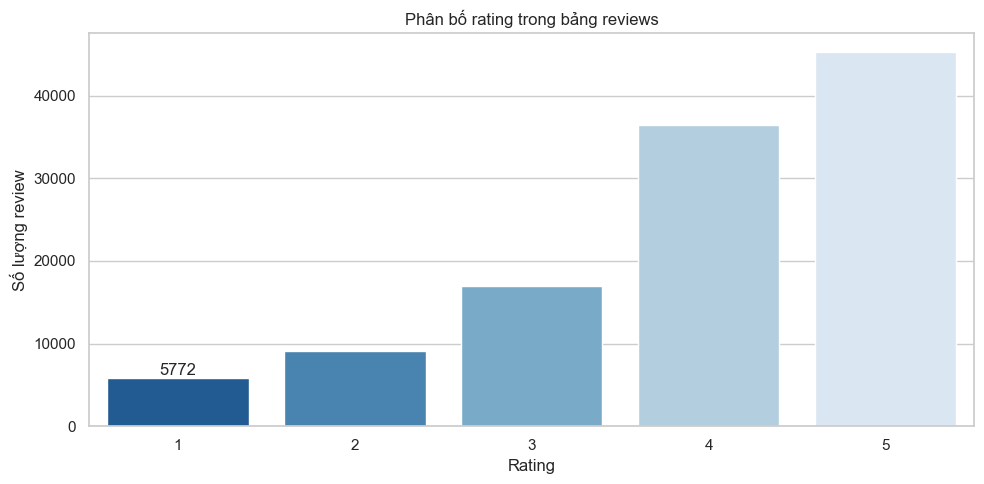

Tỷ trọng từng mức rating (%):
rating
1     5.08
2     8.01
3    14.99
4    32.07
5    39.86


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))
rating_order = [1, 2, 3, 4, 5]
sns.countplot(data=reviews, x="rating", order=rating_order, palette="Blues_r", ax=ax)
ax.set_title("Phân bố rating trong bảng reviews")
ax.set_xlabel("Rating")
ax.set_ylabel("Số lượng review")
ax.bar_label(ax.containers[0], fmt="%d")
plt.tight_layout()
plt.show()

rating_counts = reviews["rating"].value_counts().sort_index()
print("Tỷ trọng từng mức rating (%):")
print((rating_counts / rating_counts.sum() * 100).round(2).to_string())

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18380\2549164321.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_rating, x="rating", y="category", palette="viridis", ax=axes[0])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18380\2549164321.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_rating, x="rating", y="segment", palette="magma", ax=axes[1])


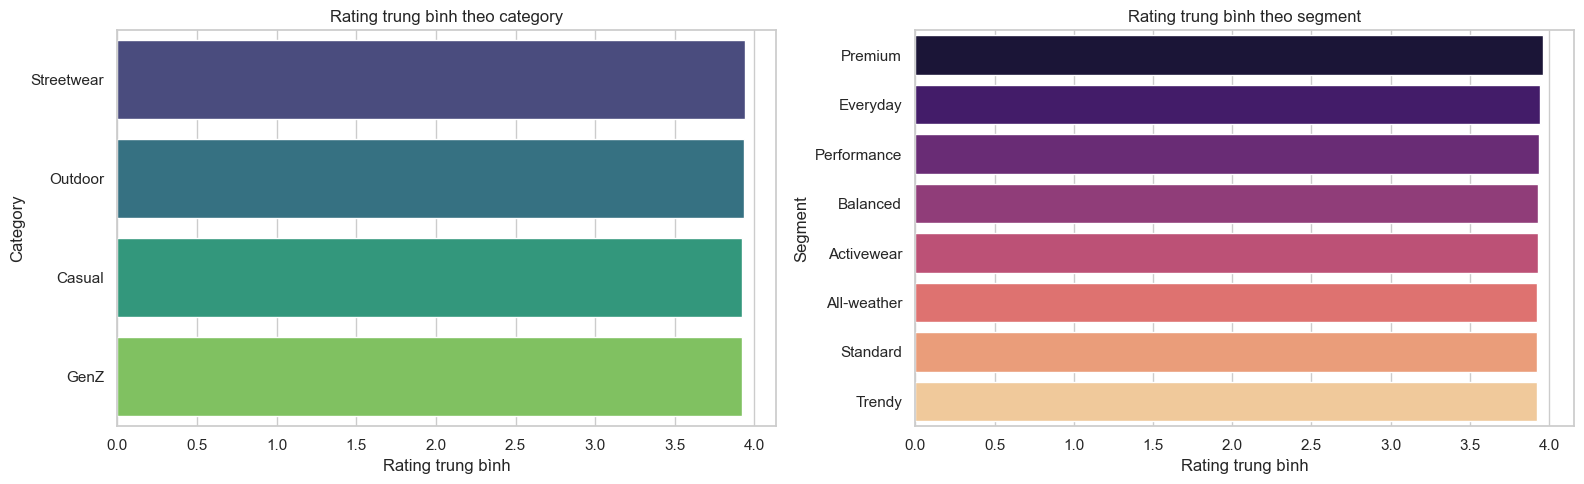

Top 10 category có rating trung bình cao nhất:
  category   rating
Streetwear 3.939398
   Outdoor 3.933891
    Casual 3.923219
      GenZ 3.922825


In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = Path(r"c:\Users\ADMIN\Documents\Datathon\datathon-2026-round-1")
reviews = pd.read_csv(base_dir / "reviews.csv", parse_dates=["review_date"])
products = pd.read_csv(base_dir / "products.csv")

review_product = reviews.merge(products[["product_id", "category", "segment"]], on="product_id", how="left")
category_rating = (
    review_product.groupby("category", dropna=False)["rating"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
segment_rating = (
    review_product.groupby("segment", dropna=False)["rating"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
sns.barplot(data=category_rating, x="rating", y="category", palette="viridis", ax=axes[0])
axes[0].set_title("Rating trung bình theo category")
axes[0].set_xlabel("Rating trung bình")
axes[0].set_ylabel("Category")

sns.barplot(data=segment_rating, x="rating", y="segment", palette="magma", ax=axes[1])
axes[1].set_title("Rating trung bình theo segment")
axes[1].set_xlabel("Rating trung bình")
axes[1].set_ylabel("Segment")

plt.tight_layout()
plt.show()

print("Top 10 category có rating trung bình cao nhất:")
print(category_rating.head(10).to_string(index=False))

## 0) Kiểm tra logic bất hợp lý theo từng bảng

Trước khi phân tích sâu, mình rà các dấu hiệu **không hợp logic** hoặc **không nhất quán** trong dữ liệu: trùng khoá nghiệp vụ, giá trị âm/bất thường, chênh lệch giữa các bảng liên kết, và các biến không khớp nhau sau khi join.

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np

base_dir = Path(r"c:\Users\ADMIN\Documents\Datathon\datathon-2026-round-1")
products = pd.read_csv(base_dir / "products.csv")
order_items = pd.read_csv(base_dir / "order_items.csv", low_memory=False)
payments = pd.read_csv(base_dir / "payments.csv")

print("=== PRODUCTS: duplicate business keys with different price/cogs ===")
product_key_cols = ["product_name", "category", "segment", "size", "color"]
product_price_flags = (
    products.groupby(product_key_cols, dropna=False)
    .agg(
        n_rows=("product_id", "count"),
        n_price=("price", "nunique"),
        n_cogs=("cogs", "nunique"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        min_cogs=("cogs", "min"),
        max_cogs=("cogs", "max"),
    )
    .reset_index()
)
product_price_flags["price_spread_pct"] = (product_price_flags["max_price"] - product_price_flags["min_price"]) / product_price_flags["min_price"].replace(0, np.nan)
product_price_flags["cogs_spread_pct"] = (product_price_flags["max_cogs"] - product_price_flags["min_cogs"]) / product_price_flags["min_cogs"].replace(0, np.nan)
problem_products = product_price_flags[(product_price_flags["n_rows"] > 1) & ((product_price_flags["n_price"] > 1) | (product_price_flags["n_cogs"] > 1))].sort_values(["n_rows", "price_spread_pct", "cogs_spread_pct"], ascending=False)
print(f"Suspicious product groups: {len(problem_products):,}")
print(problem_products.head(5).to_string(index=False) if len(problem_products) else "No suspicious duplicate product groups found.")

print("\n=== ORDER_ITEMS: impossible quantities / values / duplicated mappings ===")
invalid_order_items = order_items[
    order_items["quantity"].le(0)
    | order_items["unit_price"].le(0)
    | order_items["discount_amount"].lt(0)
    | order_items["discount_amount"].gt(order_items["unit_price"] * order_items["quantity"])
    | order_items[["order_id", "product_id"]].isna().any(axis=1)
]
print(f"Invalid order_item rows: {len(invalid_order_items):,}")
print(invalid_order_items.head(5).to_string(index=False) if len(invalid_order_items) else "No invalid order_item rows found.")

order_product_dupes = (
    order_items.groupby(["order_id", "product_id"], dropna=False)
    .size()
    .reset_index(name="n_rows")
    .query("n_rows > 1")
)
print(f"Duplicated order-product pairs: {len(order_product_dupes):,}")
print(order_product_dupes.head(5).to_string(index=False) if len(order_product_dupes) else "No duplicated order-product pairs found.")

print("\n=== PAYMENTS: invalid methods / installments / negative values ===")
valid_payment_methods = {"credit_card", "cod", "paypal", "bank_transfer", "apple_pay"}
payment_flags = payments[
    payments["order_id"].isna()
    | payments["payment_method"].isna()
    | ~payments["payment_method"].isin(valid_payment_methods)
    | payments["payment_value"].le(0)
    | payments["installments"].lt(1)
    | payments["installments"].gt(12)
]
print(f"Invalid payment rows: {len(payment_flags):,}")
print(payment_flags.head(5).to_string(index=False) if len(payment_flags) else "No invalid payment rows found.")


=== PRODUCTS: duplicate business keys with different price/cogs ===
Suspicious product groups: 186
  product_name category    segment size  color  n_rows  n_price  n_cogs  min_price   max_price  min_cogs    max_cogs  price_spread_pct  cogs_spread_pct
VietMode RP-45  Outdoor Activewear    M   blue       3        3       3  11.259873 4981.022209  6.890468 3912.592945        441.369307       566.826846
VietMode RP-28  Outdoor Activewear    S  green       3        3       3  18.151312 4912.740000 10.116082 4197.936330        269.654822       413.976521
VietMode RP-18  Outdoor Activewear    L  green       3        3       3  19.726610 4781.390943 11.734756 4542.321396        241.382798       386.082732
VietMode RP-17  Outdoor Activewear    M purple       3        3       3  19.767035 4781.390943 11.639933 2627.852462        240.887111       224.761815
VietMode RP-14  Outdoor Activewear    L orange       3        3       3  27.004228 6298.740000 15.330705 5983.803000        232.250143       

In [9]:
from pathlib import Path
import pandas as pd

base_dir = Path(r"c:\Users\ADMIN\Documents\Datathon\datathon-2026-round-1")
orders = pd.read_csv(base_dir / "orders.csv", parse_dates=["order_date"])
shipments = pd.read_csv(base_dir / "shipments.csv", parse_dates=["ship_date", "delivery_date"])
returns = pd.read_csv(base_dir / "returns.csv", parse_dates=["return_date"])

print("=== ORDERS: required fields / method consistency / status profile ===")
valid_payment_methods = {"credit_card", "cod", "paypal", "bank_transfer", "apple_pay"}
valid_device_types = {"desktop", "mobile", "tablet"}

print("Observed order statuses:", sorted(orders["order_status"].dropna().astype(str).str.lower().unique().tolist()))

invalid_orders = orders[
    orders["order_id"].isna()
    | orders["order_date"].isna()
    | orders["customer_id"].isna()
    | orders["zip"].isna()
    | orders["payment_method"].isna()
    | ~orders["payment_method"].astype(str).str.lower().isin(valid_payment_methods)
    | orders["device_type"].isna()
    | ~orders["device_type"].astype(str).str.lower().isin(valid_device_types)
]
print(f"Invalid order rows: {len(invalid_orders):,}")
print(invalid_orders.head(10).to_string(index=False) if len(invalid_orders) else "No invalid order rows found.")

print("\n=== SHIPMENTS: shipment must not precede order / delivery must not precede shipment ===")
shipments_joined = shipments.merge(orders[["order_id", "order_date"]], on="order_id", how="left")
invalid_shipments = shipments_joined[
    shipments_joined["order_id"].isna()
    | shipments_joined["ship_date"].isna()
    | shipments_joined["delivery_date"].isna()
    | shipments_joined["ship_date"].lt(shipments_joined["order_date"])
    | shipments_joined["delivery_date"].lt(shipments_joined["ship_date"])
    | shipments_joined["shipping_fee"].lt(0)
]
print(f"Invalid shipment rows: {len(invalid_shipments):,}")
print(invalid_shipments.head(10).to_string(index=False) if len(invalid_shipments) else "No invalid shipment rows found.")

print("\n=== RETURNS: return must not precede order / negative refund / quantity ===")
returns_joined = returns.merge(orders[["order_id", "order_date"]], on="order_id", how="left")
invalid_returns = returns_joined[
    returns_joined["order_id"].isna()
    | returns_joined["product_id"].isna()
    | returns_joined["return_date"].isna()
    | returns_joined["return_date"].lt(returns_joined["order_date"])
    | returns_joined["return_quantity"].le(0)
    | returns_joined["refund_amount"].lt(0)
]
print(f"Invalid return rows: {len(invalid_returns):,}")
print(invalid_returns.head(10).to_string(index=False) if len(invalid_returns) else "No invalid return rows found.")

returns_by_order = returns.groupby("order_id", as_index=False).agg(
    n_returns=("return_id", "count"),
    total_refund=("refund_amount", "sum"),
)
print(f"Orders with multiple return records: {int((returns_by_order['n_returns'] > 1).sum()):,}")


=== ORDERS: required fields / method consistency / status profile ===
Observed order statuses: ['cancelled', 'created', 'delivered', 'paid', 'returned', 'shipped']
Invalid order rows: 0
No invalid order rows found.

=== SHIPMENTS: shipment must not precede order / delivery must not precede shipment ===
Invalid shipment rows: 0
No invalid shipment rows found.

=== RETURNS: return must not precede order / negative refund / quantity ===
Invalid return rows: 0
No invalid return rows found.
Orders with multiple return records: 3,801


In [7]:
from pathlib import Path
import pandas as pd

base_dir = Path(r"c:\Users\ADMIN\Documents\Datathon\datathon-2026-round-1")
inventory = pd.read_csv(base_dir / "inventory.csv", parse_dates=["snapshot_date"])
promotions = pd.read_csv(base_dir / "promotions.csv", parse_dates=["start_date", "end_date"])

print("=== INVENTORY: impossible flags / rates outside bounds ===")
inv_flags = inventory.copy()
invalid_inventory = inv_flags[
    inv_flags["stock_on_hand"].lt(0)
    | inv_flags["units_received"].lt(0)
    | inv_flags["units_sold"].lt(0)
    | inv_flags["stockout_days"].lt(0)
    | inv_flags["days_of_supply"].lt(0)
    | inv_flags["fill_rate"].lt(0)
    | inv_flags["fill_rate"].gt(1)
    | inv_flags["sell_through_rate"].lt(0)
    | inv_flags["sell_through_rate"].gt(1)
    | ((inv_flags["stockout_flag"] == 1) & (inv_flags["stock_on_hand"] > 0))
    | ((inv_flags["overstock_flag"] == 1) & (inv_flags["stock_on_hand"] <= 0))
]
print(f"Invalid inventory rows: {len(invalid_inventory):,}")
print(invalid_inventory.head(10).to_string(index=False) if len(invalid_inventory) else "No invalid inventory rows found.")

print("\n=== PROMOTIONS: date logic / discount bounds / stackability ===")
invalid_promotions = promotions[
    promotions["promo_id"].isna()
    | promotions["promo_name"].isna()
    | promotions["promo_type"].isna()
    | promotions["discount_value"].lt(0)
    | promotions["discount_value"].gt(1)
    | promotions["start_date"].isna()
    | promotions["end_date"].isna()
    | promotions["start_date"].gt(promotions["end_date"])
    | promotions["stackable_flag"].isna()
    | ~promotions["stackable_flag"].astype(str).str.lower().isin({"yes", "no", "true", "false", "1", "0"})
]
print(f"Invalid promotion rows: {len(invalid_promotions):,}")
print(invalid_promotions.head(10).to_string(index=False) if len(invalid_promotions) else "No invalid promotion rows found.")


=== INVENTORY: impossible flags / rates outside bounds ===
Invalid inventory rows: 40,571
snapshot_date  product_id  stock_on_hand  units_received  units_sold  stockout_days  days_of_supply  fill_rate  stockout_flag  overstock_flag  reorder_flag  sell_through_rate     product_name category     segment  year  month
   2022-10-31           1              3               1           1              2            90.0     0.9333              1               0             0             0.2500 DragonWear MA-01   Casual All-weather  2022     10
   2022-11-30           1              3               1           1              1            90.0     0.9667              1               0             0             0.2500 DragonWear MA-01   Casual All-weather  2022     11
   2022-12-31           1              3               1           1              1            90.0     0.9667              1               0             0             0.2500 DragonWear MA-01   Casual All-weather  2022     12
   201

In [10]:
from pathlib import Path
import pandas as pd

base_dir = Path(r"c:\Users\ADMIN\Documents\Datathon\datathon-2026-round-1")
customers = pd.read_csv(base_dir / "customers.csv", parse_dates=["signup_date"])
geography = pd.read_csv(base_dir / "geography.csv")
reviews = pd.read_csv(base_dir / "reviews.csv", parse_dates=["review_date"])
sales = pd.read_csv(base_dir / "sales.csv", parse_dates=["Date"])
web_traffic = pd.read_csv(base_dir / "web_traffic.csv", parse_dates=["date"])

print("=== CUSTOMERS & GEOGRAPHY: key format / reference mismatches ===")
valid_age_groups = {"18-24", "25-34", "35-44", "45-54", "55+"}
customer_flags = customers.copy()
invalid_customers = customer_flags[
    customer_flags["customer_id"].isna()
    | customer_flags["zip"].isna()
    | customer_flags["signup_date"].isna()
    | customer_flags["gender"].isna()
    | (customer_flags["age_group"].notna() & ~customer_flags["age_group"].isin(valid_age_groups))
]
zip_geo = geography.groupby("zip", as_index=False).agg(n_city=("city", "nunique"), n_region=("region", "nunique"), n_district=("district", "nunique"))
inconsistent_geo = zip_geo[(zip_geo["n_city"] > 1) | (zip_geo["n_region"] > 1) | (zip_geo["n_district"] > 1)]
print(f"Invalid customer rows: {len(invalid_customers):,}")
print(invalid_customers.head(10).to_string(index=False) if len(invalid_customers) else "No invalid customer rows found.")
print(f"Zip codes with inconsistent geography mapping: {len(inconsistent_geo):,}")
print(inconsistent_geo.head(10).to_string(index=False) if len(inconsistent_geo) else "No inconsistent geography mappings found.")

print("\n=== REVIEWS: rating / date / duplicated review patterns ===")
invalid_reviews = reviews[
    reviews["review_id"].isna()
    | reviews["order_id"].isna()
    | reviews["product_id"].isna()
    | reviews["customer_id"].isna()
    | reviews["review_date"].isna()
    | reviews["rating"].lt(1)
    | reviews["rating"].gt(5)
]
print(f"Invalid review rows: {len(invalid_reviews):,}")
print(invalid_reviews.head(10).to_string(index=False) if len(invalid_reviews) else "No invalid review rows found.")

review_dupes = reviews.groupby(["order_id", "product_id", "customer_id"], dropna=False).size().reset_index(name="n_rows")
review_dupes = review_dupes[review_dupes["n_rows"] > 1]
print(f"Duplicated review triplets: {len(review_dupes):,}")
print(review_dupes.head(10).to_string(index=False) if len(review_dupes) else "No duplicated review triplets found.")

print("\n=== SALES & WEB TRAFFIC: time series logic / zero values / bounds ===")
invalid_sales = sales[
    sales["Date"].isna()
    | sales["Revenue"].lt(0)
    | sales["COGS"].lt(0)
]
print(f"Invalid sales rows: {len(invalid_sales):,}")
print(invalid_sales.head(10).to_string(index=False) if len(invalid_sales) else "No invalid sales rows found.")

invalid_traffic = web_traffic[
    web_traffic["date"].isna()
    | web_traffic["sessions"].lt(0)
    | web_traffic["unique_visitors"].lt(0)
    | web_traffic["page_views"].lt(0)
    | web_traffic["bounce_rate"].lt(0)
    | web_traffic["bounce_rate"].gt(1)
    | web_traffic["avg_session_duration_sec"].lt(0)
]
print(f"Invalid traffic rows: {len(invalid_traffic):,}")
print(invalid_traffic.head(10).to_string(index=False) if len(invalid_traffic) else "No invalid traffic rows found.")


=== CUSTOMERS & GEOGRAPHY: key format / reference mismatches ===
Invalid customer rows: 0
No invalid customer rows found.
Zip codes with inconsistent geography mapping: 0
No inconsistent geography mappings found.

=== REVIEWS: rating / date / duplicated review patterns ===
Invalid review rows: 0
No invalid review rows found.
Duplicated review triplets: 0
No duplicated review triplets found.

=== SALES & WEB TRAFFIC: time series logic / zero values / bounds ===
Invalid sales rows: 0
No invalid sales rows found.
Invalid traffic rows: 0
No invalid traffic rows found.


## 1) Chuẩn hoá lớp dữ liệu phân tích (Master Analytical Table)

Cell dưới đây tạo bảng sự kiện ở cấp `order_id x product_id`, kết hợp thông tin bán hàng, sản phẩm, khách hàng, địa lý, giao hàng, hoàn trả, đánh giá và khuyến mãi.
Đây là nền cho các trực quan và insight phía sau.

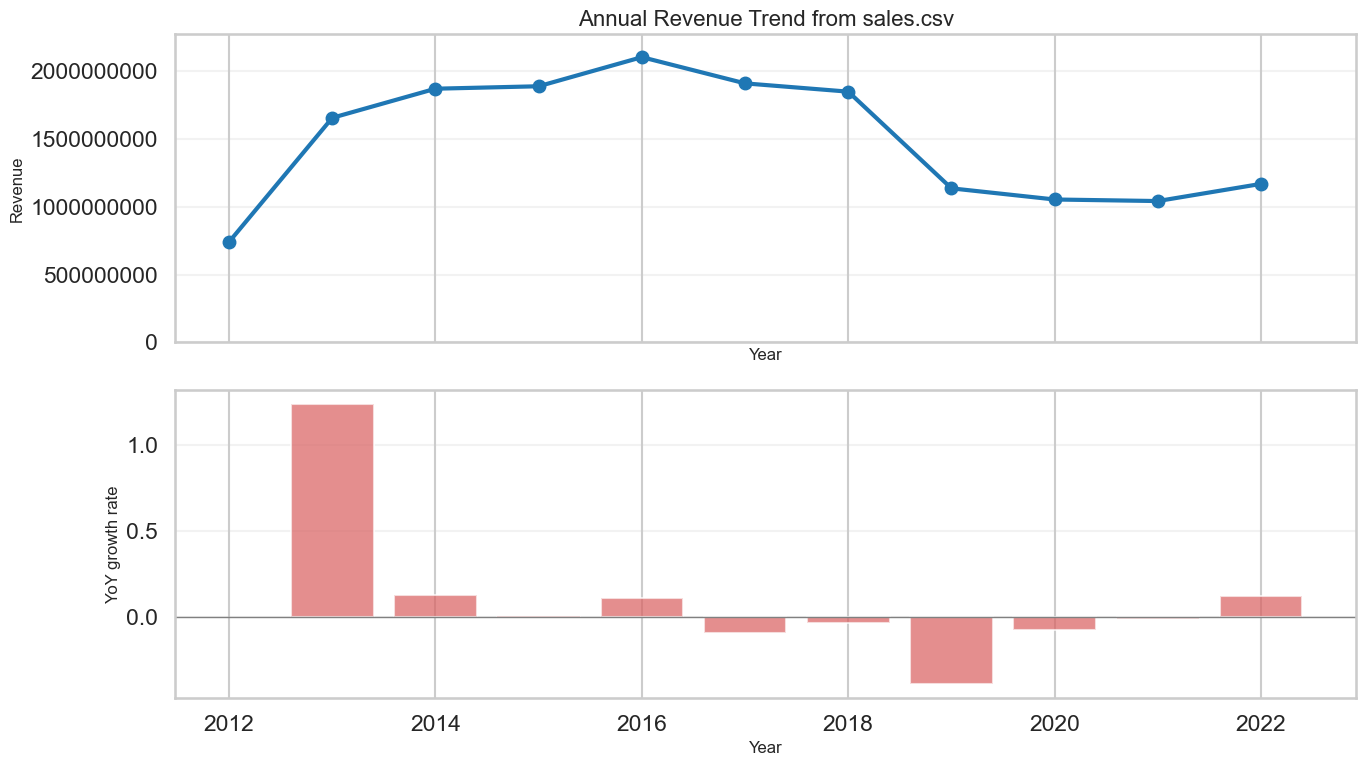

,year,revenue,cogs,gross_margin,revenue_yoy
0,2012,7.414977e+08,5.874619e+08,0.207736,NaN
1,2013,1.657169e+09,1.465980e+09,0.115371,1.234895
2,2014,1.871846e+09,1.574607e+09,0.158794,0.129544
3,2015,1.889934e+09,1.665442e+09,0.118783,0.009663
4,2016,2.104641e+09,1.780559e+09,0.153984,0.113605
5,2017,1.911164e+09,1.694386e+09,0.113427,-0.091928
6,2018,1.850122e+09,1.542176e+09,0.166447,-0.031940
7,2019,1.136801e+09,1.005203e+09,0.115762,-0.385553
8,2020,1.054512e+09,8.860851e+08,0.159720,-0.072387
9,2021,1.043040e+09,9.411301e+08,0.097705,-0.010879


In [12]:
# Annual revenue trend from sales.csv
sales_yearly = sales.copy()
sales_yearly["year"] = sales_yearly["Date"].dt.year
annual_revenue = sales_yearly.groupby("year", as_index=False).agg(
    revenue=("Revenue", "sum"),
    cogs=("COGS", "sum")
)
annual_revenue["gross_margin"] = (annual_revenue["revenue"] - annual_revenue["cogs"]) / annual_revenue["revenue"]
annual_revenue["revenue_yoy"] = annual_revenue["revenue"].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(
    annual_revenue["year"],
    annual_revenue["revenue"],
    marker="o",
    linewidth=3,
    color="#1f77b4",
)
axes[0].set_title("Annual Revenue Trend from sales.csv")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Revenue")
axes[0].ticklabel_format(style="plain", axis="y")
axes[0].set_ylim(0, annual_revenue["revenue"].max() * 1.08)
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].bar(
    annual_revenue["year"],
    annual_revenue["revenue_yoy"],
    color="#d95f5f",
    alpha=0.7,
)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("YoY growth rate")
axes[1].axhline(0, color="gray", linewidth=1)
axes[1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

display(annual_revenue)

In [3]:
# Order-level enrichments
payments_order = payments.groupby("order_id", as_index=False).agg(
    payment_value=("payment_value", "sum"),
    installments=("installments", "max"),
)

shipments_order = shipments.copy()
shipments_order["delivery_days"] = (shipments_order["delivery_date"] - shipments_order["ship_date"]).dt.days
shipments_order = shipments_order.groupby("order_id", as_index=False).agg(
    ship_date=("ship_date", "min"),
    delivery_date=("delivery_date", "max"),
    shipping_fee=("shipping_fee", "sum"),
    delivery_days=("delivery_days", "mean"),
)

returns_item = returns.groupby(["order_id", "product_id"], as_index=False).agg(
    return_records=("return_id", "count"),
    return_quantity=("return_quantity", "sum"),
    refund_amount=("refund_amount", "sum"),
)

reviews_item = reviews.groupby(["order_id", "product_id"], as_index=False).agg(
    avg_rating=("rating", "mean"),
    review_count=("review_id", "count"),
)

customer_geo = customers.merge(geography[["zip", "region", "district"]].drop_duplicates("zip"), on="zip", how="left")

orders_master = (
    orders
    .merge(customer_geo[["customer_id", "gender", "age_group", "acquisition_channel", "region", "district", "signup_date"]], on="customer_id", how="left")
    .merge(payments_order, on="order_id", how="left")
    .merge(shipments_order, on="order_id", how="left")
)

line_items = (
    order_items
    .merge(orders_master, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(returns_item, on=["order_id", "product_id"], how="left")
    .merge(reviews_item, on=["order_id", "product_id"], how="left")
    .merge(promotions[["promo_id", "promo_type", "promo_channel", "stackable_flag", "discount_value"]], on="promo_id", how="left")
)

line_items["gross_revenue"] = line_items["quantity"] * line_items["unit_price"]
line_items["net_revenue"] = line_items["gross_revenue"] - line_items["discount_amount"].fillna(0)
line_items["line_cogs"] = line_items["quantity"] * line_items["cogs"]
line_items["gross_profit"] = line_items["net_revenue"] - line_items["line_cogs"]
line_items["is_returned"] = line_items["return_records"].fillna(0).gt(0)
line_items["order_month"] = line_items["order_date"].dt.to_period("M").dt.to_timestamp()
line_items["promo_applied"] = line_items["promo_id"].notna()

print("line_items shape:", line_items.shape)
line_items[["order_id", "product_id", "order_date", "category", "segment", "net_revenue", "gross_profit", "is_returned"]].head()

line_items shape: (714669, 49)


,order_id,product_id,order_date,category,segment,net_revenue,gross_profit,is_returned
0,1,2400,2012-07-04,GenZ,Trendy,7967.54,590.953941,False
1,2,609,2012-07-04,Streetwear,Everyday,71163.75,8249.820384,True
2,3,396,2012-07-04,Streetwear,Balanced,33660.99,3387.953233,False
3,4,635,2012-07-04,Streetwear,Everyday,53196.25,7169.097610,False
4,6,1935,2012-07-06,Outdoor,Activewear,1597.84,549.143643,False


## 2) Descriptive — Toàn cảnh doanh thu, lợi nhuận, đơn hàng

### Vì sao góc nhìn này quan trọng?
Đây là lớp nền để xác định quy mô và nhịp vận hành theo thời gian, giúp phát hiện giai đoạn tăng trưởng/chững lại trước khi đào sâu nguyên nhân.

,KPI,Value
0,Total Orders,"646,945"
1,Total Customers,"121,930"
2,Total Net Revenue,"15,680,869,265"
3,Total Gross Profit,"1,517,418,746"
4,Gross Margin,9.68%
5,Line Return Rate,5.59%
6,Order Cancel Rate,9.19%
7,Avg Review Rating,3.94


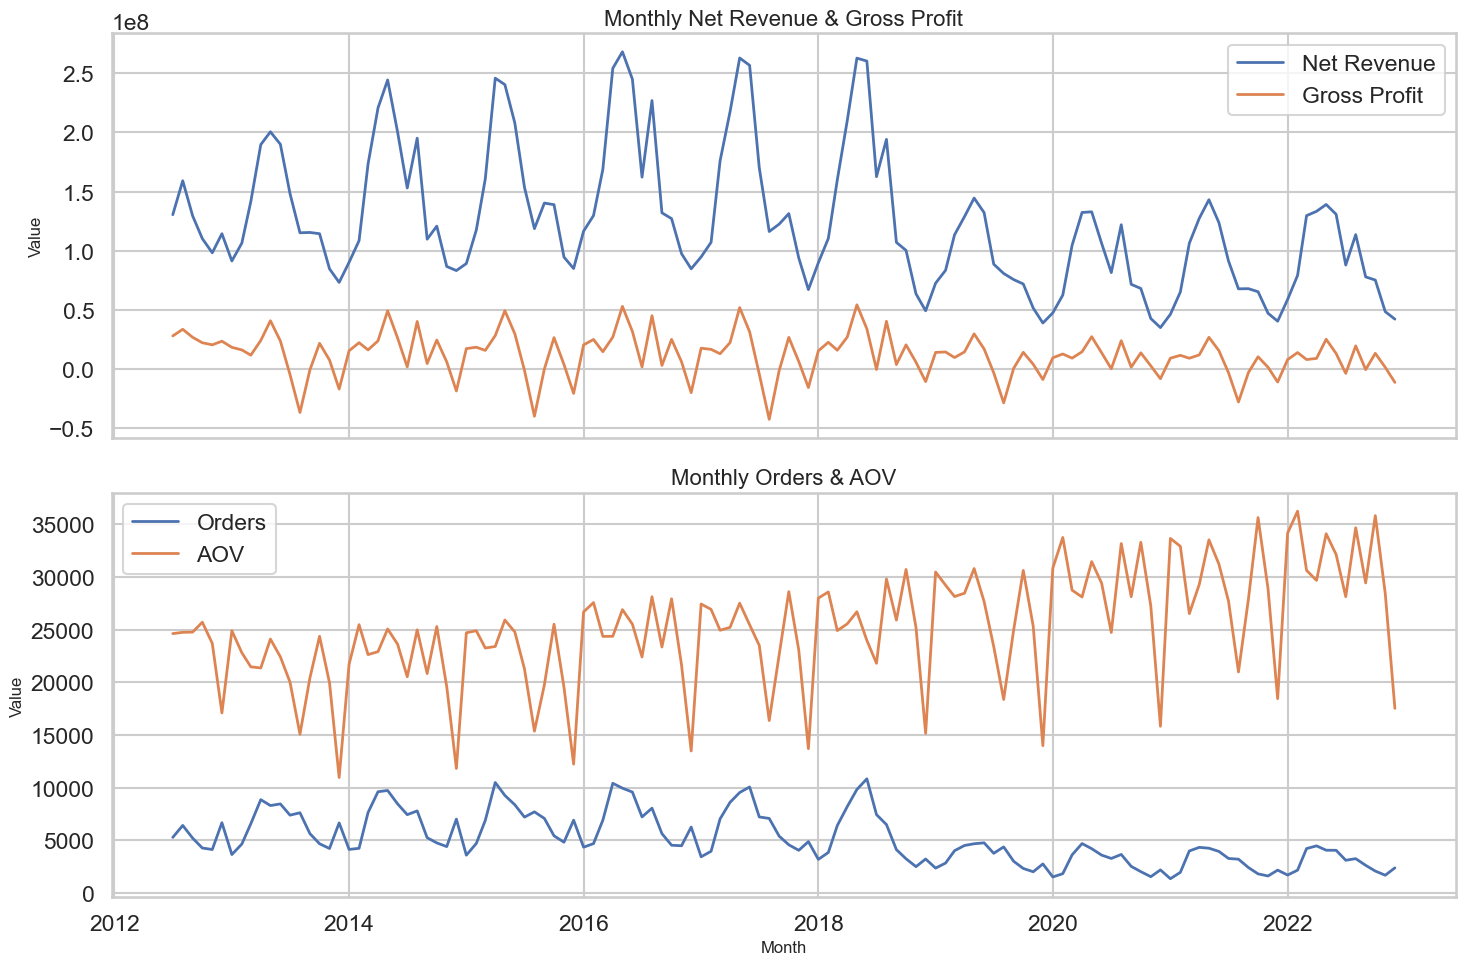

In [5]:
# KPI overview
total_orders = orders["order_id"].nunique()
total_customers = customers["customer_id"].nunique()
net_revenue_total = line_items["net_revenue"].sum()
gross_profit_total = line_items["gross_profit"].sum()
gross_margin_total = gross_profit_total / net_revenue_total
return_rate_lines = line_items["is_returned"].mean()
cancel_rate = (orders["order_status"] == "cancelled").mean()
avg_rating = reviews["rating"].mean()

kpi = pd.DataFrame({
    "KPI": ["Total Orders", "Total Customers", "Total Net Revenue", "Total Gross Profit", "Gross Margin", "Line Return Rate", "Order Cancel Rate", "Avg Review Rating"],
    "Value": [
        f"{total_orders:,.0f}",
        f"{total_customers:,.0f}",
        f"{net_revenue_total:,.0f}",
        f"{gross_profit_total:,.0f}",
        f"{gross_margin_total:.2%}",
        f"{return_rate_lines:.2%}",
        f"{cancel_rate:.2%}",
        f"{avg_rating:.2f}",
    ]
})

display(kpi)

monthly = line_items.groupby("order_month", as_index=False).agg(
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    orders=("order_id", "nunique"),
)
monthly["aov"] = monthly["revenue"] / monthly["orders"]

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].plot(monthly["order_month"], monthly["revenue"], label="Net Revenue", linewidth=2)
axes[0].plot(monthly["order_month"], monthly["gross_profit"], label="Gross Profit", linewidth=2)
axes[0].set_title("Monthly Net Revenue & Gross Profit")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].plot(monthly["order_month"], monthly["orders"], label="Orders", linewidth=2)
axes[1].plot(monthly["order_month"], monthly["aov"], label="AOV", linewidth=2)
axes[1].set_title("Monthly Orders & AOV")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Value")
axes[1].legend()

plt.tight_layout()
plt.show()

**Phân tích & hàm ý kinh doanh**

- Biểu đồ cho thấy nhịp tăng/giảm đồng thời giữa doanh thu và lợi nhuận, giúp phát hiện tháng tăng trưởng không đi kèm hiệu quả biên.
- Nếu `AOV` tăng nhưng số đơn giảm, khả năng đang tối ưu giá trị đơn thay vì mở rộng tệp khách; cần kiểm tra tính bền vững theo kênh.
- Giai đoạn biên lợi nhuận mỏng là tín hiệu ưu tiên rà soát mix sản phẩm và mức giảm giá.

## 3) Diagnostic — Hiệu quả nguồn traffic và chất lượng chuyển đổi

### Vì sao quan trọng?
Marketing hiệu quả không chỉ là nhiều phiên truy cập, mà còn là **đơn hàng tạo ra trên mỗi phiên** và chất lượng traffic (bounce rate).

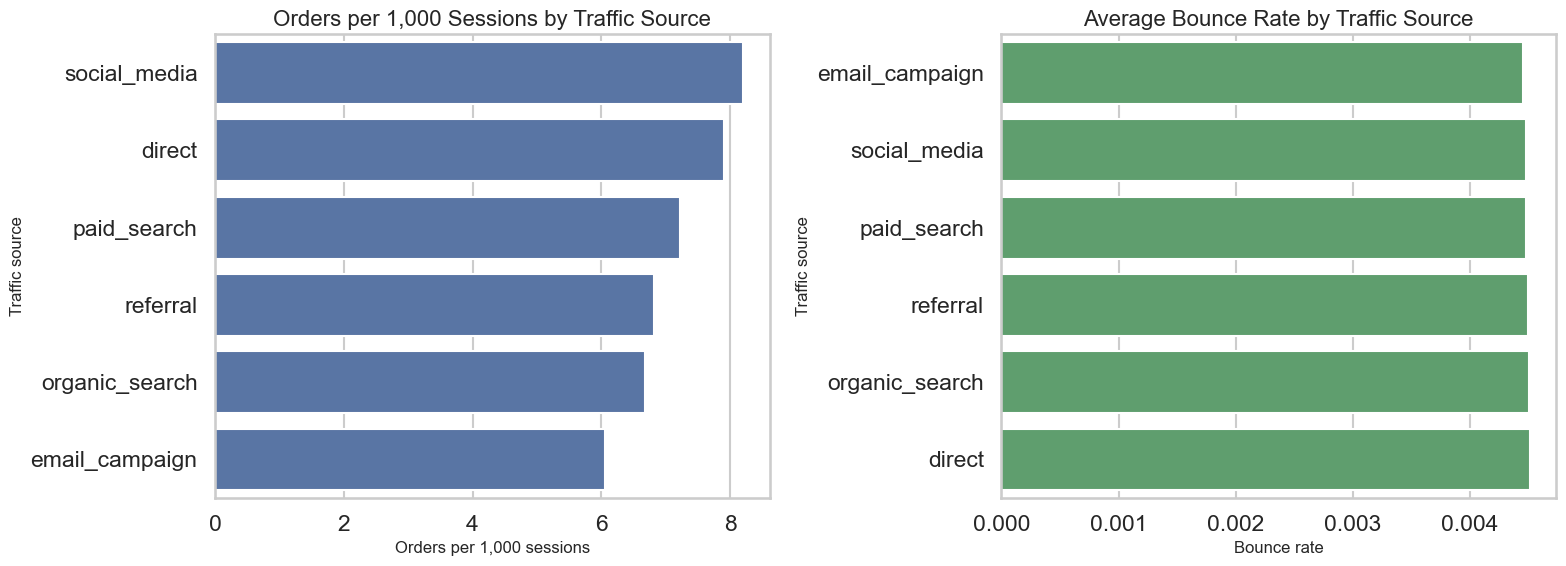

,traffic_source,sessions,orders,orders_per_1k_sessions,avg_bounce_rate,avg_session_duration
5,social_media,15816226,129710,8.201071,0.004476,210.290190
0,direct,6571549,51951,7.905442,0.004511,207.678195
3,paid_search,19598271,141652,7.227780,0.004478,209.362117
4,referral,9476845,64565,6.812921,0.004499,207.558667
2,organic_search,27196976,181495,6.673352,0.004504,211.153945
1,email_campaign,12792670,77572,6.063785,0.004458,213.220594


In [6]:
traffic_src = web_traffic.groupby("traffic_source", as_index=False).agg(
    sessions=("sessions", "sum"),
    avg_bounce_rate=("bounce_rate", "mean"),
    avg_session_duration=("avg_session_duration_sec", "mean"),
)

orders_src = orders.groupby("order_source", as_index=False).agg(orders=("order_id", "nunique"))

efficiency = traffic_src.merge(orders_src, left_on="traffic_source", right_on="order_source", how="left")
efficiency["orders"] = efficiency["orders"].fillna(0)
efficiency["orders_per_1k_sessions"] = efficiency["orders"] / efficiency["sessions"] * 1000

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=efficiency.sort_values("orders_per_1k_sessions", ascending=False),
            x="orders_per_1k_sessions", y="traffic_source", ax=axes[0], color="#4C72B0")
axes[0].set_title("Orders per 1,000 Sessions by Traffic Source")
axes[0].set_xlabel("Orders per 1,000 sessions")
axes[0].set_ylabel("Traffic source")

sns.barplot(data=efficiency.sort_values("avg_bounce_rate"),
            x="avg_bounce_rate", y="traffic_source", ax=axes[1], color="#55A868")
axes[1].set_title("Average Bounce Rate by Traffic Source")
axes[1].set_xlabel("Bounce rate")
axes[1].set_ylabel("Traffic source")

plt.tight_layout()
plt.show()

display(efficiency.sort_values("orders_per_1k_sessions", ascending=False)[[
    "traffic_source", "sessions", "orders", "orders_per_1k_sessions", "avg_bounce_rate", "avg_session_duration"
]])

**Phân tích & hàm ý kinh doanh**

- So sánh đồng thời `orders_per_1k_sessions` và `bounce_rate` giúp phân biệt nguồn traffic “nhiều nhưng kém chất lượng” với nguồn hiệu quả thật sự.
- Nguồn có bounce thấp nhưng đơn/1k thấp thường gặp vấn đề ở bước sản phẩm/giỏ hàng/thanh toán, thay vì do quảng cáo.
- Khuyến nghị: ưu tiên ngân sách cho nguồn có hiệu suất chuyển đổi cao và chạy A/B test landing page cho nguồn bounce cao.

## 4) Diagnostic — Khuyến mãi có thực sự tạo giá trị?

Kết hợp `order_items` + `promotions` để đo ảnh hưởng của promo tới doanh thu/biên lợi nhuận/hoàn trả.

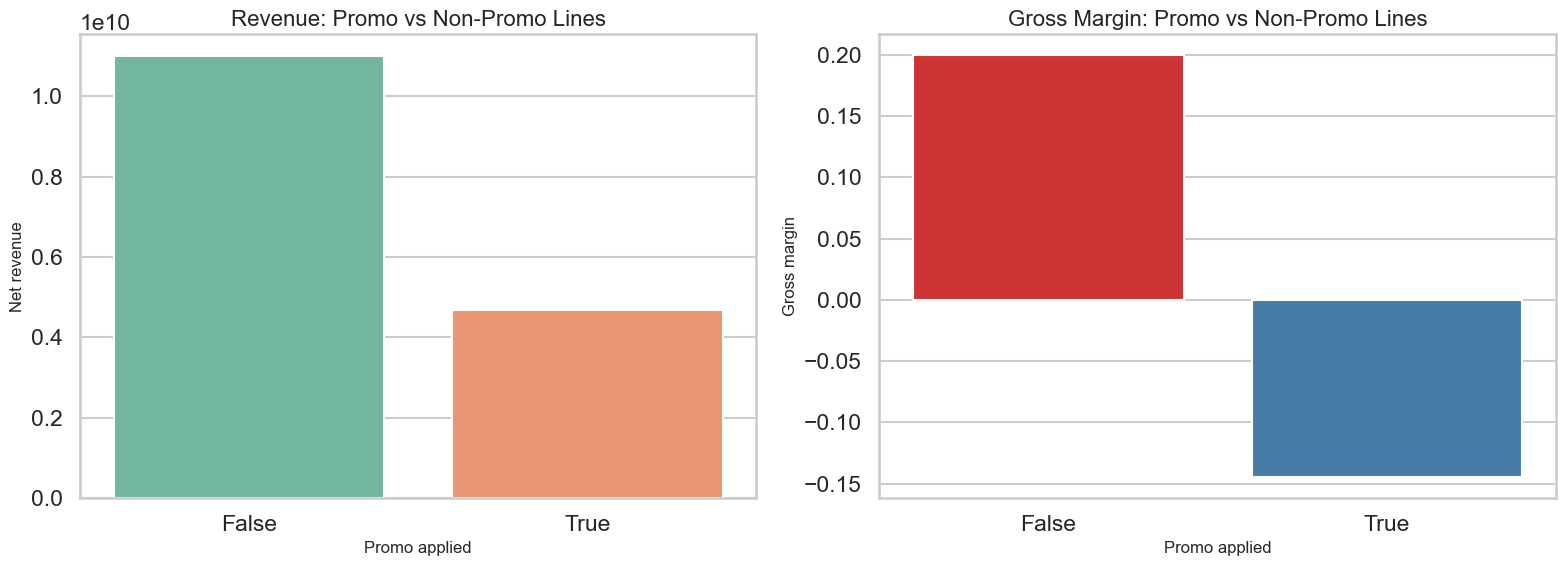

,promo_applied,lines,revenue,gross_profit,avg_discount,return_rate,gross_margin
0,False,438353,1.099504e+10,2.195015e+09,0.00000,0.055898,0.199637
1,True,276316,4.685830e+09,-6.775966e+08,2712.86252,0.055864,-0.144605


,promo_type,revenue,gross_margin,return_rate
1,percentage,4.314083e+09,-0.102534,0.055838
0,fixed,3.717472e+08,-0.632842,0.056181


In [7]:
promo_analysis = line_items.groupby("promo_applied", as_index=False).agg(
    lines=("order_id", "count"),
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_discount=("discount_amount", "mean"),
    return_rate=("is_returned", "mean"),
)
promo_analysis["gross_margin"] = promo_analysis["gross_profit"] / promo_analysis["revenue"]

promo_type_analysis = (
    line_items[line_items["promo_applied"]]
    .groupby("promo_type", as_index=False)
    .agg(
        revenue=("net_revenue", "sum"),
        gross_margin=("gross_profit", lambda x: x.sum() / line_items.loc[x.index, "net_revenue"].sum() if line_items.loc[x.index, "net_revenue"].sum() else np.nan),
        return_rate=("is_returned", "mean"),
    )
    .sort_values("revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=promo_analysis, x="promo_applied", y="revenue", ax=axes[0], palette="Set2")
axes[0].set_title("Revenue: Promo vs Non-Promo Lines")
axes[0].set_xlabel("Promo applied")
axes[0].set_ylabel("Net revenue")

sns.barplot(data=promo_analysis, x="promo_applied", y="gross_margin", ax=axes[1], palette="Set1")
axes[1].set_title("Gross Margin: Promo vs Non-Promo Lines")
axes[1].set_xlabel("Promo applied")
axes[1].set_ylabel("Gross margin")

plt.tight_layout()
plt.show()

display(promo_analysis)
display(promo_type_analysis)

**Phân tích & hàm ý kinh doanh**

- Nếu promo giúp tăng doanh thu nhưng làm giảm mạnh biên lợi nhuận, cần tối ưu ngưỡng áp dụng theo danh mục/segment.
- Theo dõi đồng thời `return_rate` cho đơn có promo để tránh “mua theo khuyến mãi rồi hoàn trả”.
- Khuyến nghị: chuyển từ giảm giá đại trà sang promo theo phân khúc có `gross_margin` cao và tỷ lệ hoàn thấp.

## 5) Diagnostic — Quan hệ giữa hoàn trả và đánh giá khách hàng

Kết hợp `returns` và `reviews` để tìm nhóm sản phẩm vừa có tỷ lệ hoàn trả cao, vừa rating thấp (điểm đau về chất lượng/fit).

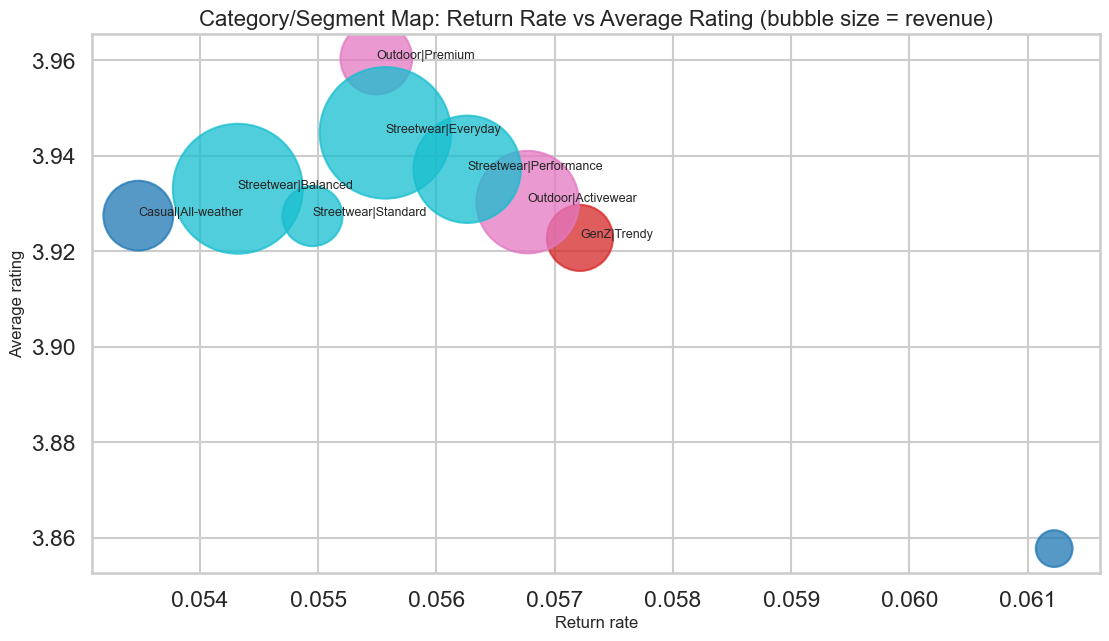

,category,segment,revenue,return_rate,avg_rating,lines
0,Casual,Activewear,3.152008e+07,0.061224,3.857759,1421
2,GenZ,Trendy,3.287102e+08,0.057214,3.922825,37159
3,Outdoor,Activewear,1.899185e+09,0.056771,3.930323,228954
7,Streetwear,Performance,2.285029e+09,0.056260,3.937205,96730
6,Streetwear,Everyday,5.147455e+09,0.055568,3.944827,182533
4,Outdoor,Premium,4.542119e+08,0.055491,3.960384,31032
8,Streetwear,Standard,2.256749e+08,0.054951,3.927400,10937
5,Streetwear,Balanced,4.900318e+09,0.054320,3.933122,103333
1,Casual,All-weather,4.087651e+08,0.053478,3.927487,22570


In [8]:
cat_quality = line_items.groupby(["category", "segment"], as_index=False).agg(
    revenue=("net_revenue", "sum"),
    return_rate=("is_returned", "mean"),
    avg_rating=("avg_rating", "mean"),
    lines=("order_id", "count"),
)
cat_quality = cat_quality.replace([np.inf, -np.inf], np.nan).dropna(subset=["avg_rating"])

plt.figure(figsize=(13, 7))
sc = plt.scatter(
    cat_quality["return_rate"],
    cat_quality["avg_rating"],
    s=np.sqrt(cat_quality["revenue"]) / 8,
    c=pd.factorize(cat_quality["category"])[0],
    cmap="tab10",
    alpha=0.75,
)

for _, r in cat_quality.nlargest(8, "revenue").iterrows():
    plt.annotate(f"{r['category']}|{r['segment']}", (r["return_rate"], r["avg_rating"]), fontsize=9)

plt.title("Category/Segment Map: Return Rate vs Average Rating (bubble size = revenue)")
plt.xlabel("Return rate")
plt.ylabel("Average rating")
plt.show()

display(cat_quality.sort_values(["return_rate", "avg_rating"], ascending=[False, True]).head(12))

**Phân tích & hàm ý kinh doanh**

- Nhóm nằm ở vùng **return cao + rating thấp** là ưu tiên số 1 cho cải tiến sản phẩm/mô tả size/chất lượng.
- Nhóm **rating cao nhưng return vẫn cao** thường liên quan kỳ vọng giao nhận hoặc mismatch size chart.
- Hành động: cập nhật size guide theo segment, bổ sung ảnh/video thực tế, và thiết lập rule QA cho SKU có refund lớn.

## 6) Diagnostic — Logistics: thời gian giao hàng và chi phí vận chuyển

Dùng `shipments` + `orders` + `geography` để xem vùng nào có lead time cao, tác động tới trải nghiệm và hoàn trả.

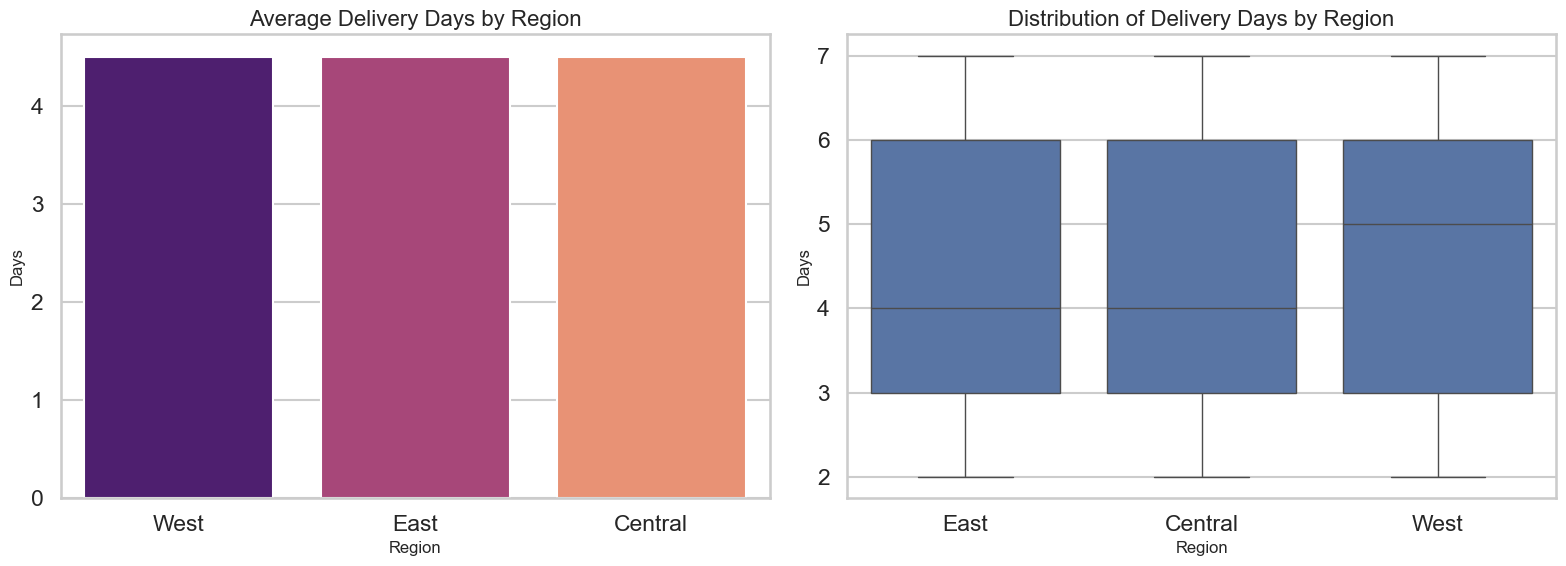

,region,avg_delivery_days,median_delivery_days,avg_shipping_fee,orders
2,West,4.499677,5.0,5.389595,167642
1,East,4.499302,4.0,4.827388,294612
0,Central,4.498637,4.0,4.790728,184691


In [9]:
ship_analysis = orders[["order_id", "order_status", "zip"]].merge(
    shipments_order[["order_id", "delivery_days", "shipping_fee"]], on="order_id", how="left"
).merge(
    geography[["zip", "region"]].drop_duplicates("zip"), on="zip", how="left"
)

ship_summary = ship_analysis.groupby("region", as_index=False).agg(
    avg_delivery_days=("delivery_days", "mean"),
    median_delivery_days=("delivery_days", "median"),
    avg_shipping_fee=("shipping_fee", "mean"),
    orders=("order_id", "nunique"),
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=ship_summary.sort_values("avg_delivery_days", ascending=False),
            x="region", y="avg_delivery_days", ax=axes[0], palette="magma")
axes[0].set_title("Average Delivery Days by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Days")

sns.boxplot(data=ship_analysis.dropna(subset=["delivery_days"]), x="region", y="delivery_days", ax=axes[1])
axes[1].set_title("Distribution of Delivery Days by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Days")

plt.tight_layout()
plt.show()

display(ship_summary.sort_values("avg_delivery_days", ascending=False))

**Phân tích & hàm ý kinh doanh**

- Vùng có `delivery_days` cao hơn mặt bằng cần ưu tiên tối ưu tuyến giao, đặc biệt nếu đi cùng `return_reason = late_delivery`.
- Chênh lệch lớn giữa trung bình và trung vị gợi ý có đuôi phân phối dài (outlier giao trễ), cần SLA theo percentile thay vì chỉ mean.
- Hành động: thiết lập cảnh báo đơn có nguy cơ trễ theo vùng + đối tác vận chuyển.

## 7) Diagnostic — Inventory health và rủi ro mất doanh thu

Sử dụng `inventory` kết hợp tín hiệu bán hàng theo thời gian để tìm phân khúc gặp stockout/overstock kéo dài.

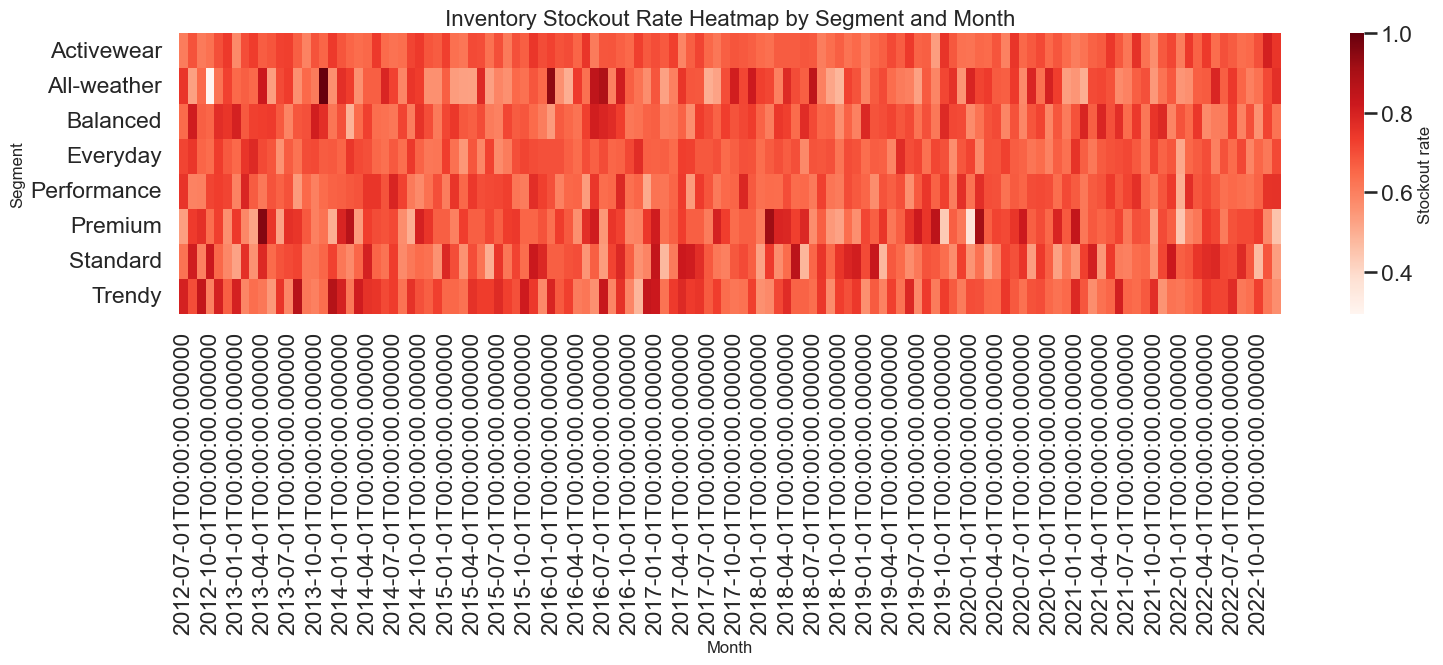

,month,segment,stockout_rate,overstock_rate,avg_fill_rate,avg_sell_through,avg_days_of_supply
1001,2022-12-01,All-weather,0.763158,0.763158,0.961403,0.133363,869.950000
1004,2022-12-01,Performance,0.760000,0.740000,0.952668,0.128174,2212.482000
1000,2022-12-01,Activewear,0.750000,0.826923,0.949684,0.099491,2825.271154
1003,2022-12-01,Everyday,0.708333,0.944444,0.962504,0.077875,3319.047222
1002,2022-12-01,Balanced,0.627119,0.762712,0.966668,0.144344,713.247458
1007,2022-12-01,Trendy,0.568182,0.840909,0.971970,0.117450,1019.415909
1006,2022-12-01,Standard,0.533333,0.800000,0.975560,0.124880,437.273333
1005,2022-12-01,Premium,0.452381,0.642857,0.973807,0.171195,537.535714


In [10]:
inventory["month"] = inventory["snapshot_date"].dt.to_period("M").dt.to_timestamp()
inv_seg = inventory.groupby(["month", "segment"], as_index=False).agg(
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    avg_fill_rate=("fill_rate", "mean"),
    avg_sell_through=("sell_through_rate", "mean"),
    avg_days_of_supply=("days_of_supply", "mean"),
)

pivot_stockout = inv_seg.pivot(index="segment", columns="month", values="stockout_rate")

plt.figure(figsize=(16, 7))
sns.heatmap(pivot_stockout, cmap="Reds", cbar_kws={"label": "Stockout rate"})
plt.title("Inventory Stockout Rate Heatmap by Segment and Month")
plt.xlabel("Month")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

inv_latest = inv_seg.sort_values("month").groupby("segment", as_index=False).tail(1)
display(inv_latest.sort_values("stockout_rate", ascending=False))

**Phân tích & hàm ý kinh doanh**

- Segment có `stockout_rate` cao kéo dài là vùng rò rỉ doanh thu tiềm ẩn, đặc biệt với nhóm biên lợi nhuận cao.
- Segment có `overstock_rate` cao nhưng `sell_through` thấp làm tăng chi phí tồn kho và giảm vòng quay vốn.
- Hành động: thiết kế policy tồn kho theo segment (safety stock, reorder point) thay vì một ngưỡng chung.

## 8) Diagnostic — Khách hàng & retention theo cohort

Dùng `customers` + `orders` để đo hành vi mua lại theo năm signup và kênh thu hút.

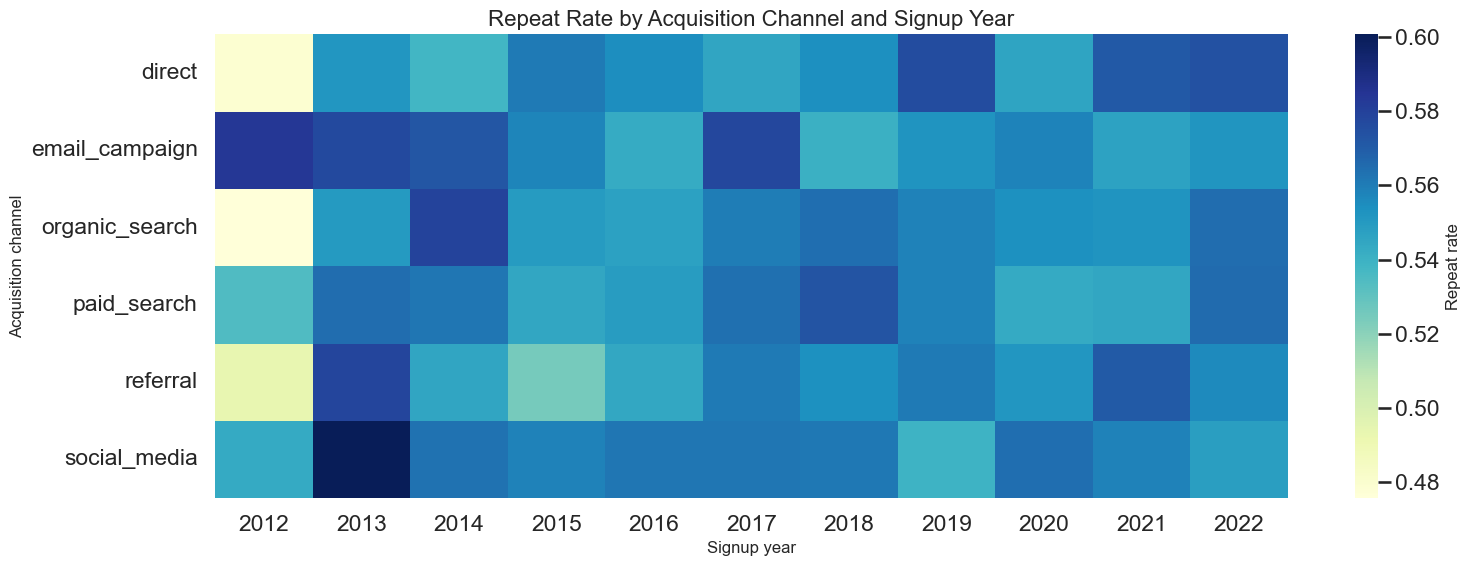

,signup_year,acquisition_channel,customers,avg_orders,repeat_rate
11,2013,social_media,591,5.759729,0.600677
9,2013,paid_search,586,5.653584,0.564846
12,2014,direct,394,5.616751,0.538071
14,2014,organic_search,1532,5.577023,0.579634
10,2013,referral,306,5.562092,0.578431
49,2020,email_campaign,2086,5.539789,0.558006
17,2014,social_media,985,5.537056,0.563452
36,2018,direct,1043,5.523490,0.554171
3,2012,paid_search,189,5.492063,0.534392
44,2019,organic_search,4452,5.458446,0.558401


In [11]:
cust_orders = orders.groupby("customer_id", as_index=False).agg(
    total_orders=("order_id", "nunique"),
    first_order=("order_date", "min"),
    last_order=("order_date", "max"),
)

cohort = customers[["customer_id", "signup_date", "acquisition_channel", "age_group"]].merge(cust_orders, on="customer_id", how="left")
cohort["total_orders"] = cohort["total_orders"].fillna(0)
cohort["is_repeat"] = cohort["total_orders"] > 1
cohort["signup_year"] = cohort["signup_date"].dt.year

cohort_summary = cohort.groupby(["signup_year", "acquisition_channel"], as_index=False).agg(
    customers=("customer_id", "nunique"),
    avg_orders=("total_orders", "mean"),
    repeat_rate=("is_repeat", "mean"),
)

pivot_repeat = cohort_summary.pivot(index="acquisition_channel", columns="signup_year", values="repeat_rate")

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_repeat, cmap="YlGnBu", cbar_kws={"label": "Repeat rate"})
plt.title("Repeat Rate by Acquisition Channel and Signup Year")
plt.xlabel("Signup year")
plt.ylabel("Acquisition channel")
plt.tight_layout()
plt.show()

display(cohort_summary.sort_values("avg_orders", ascending=False).head(15))

**Phân tích & hàm ý kinh doanh**

- Kênh có `repeat_rate` và `avg_orders` cao hơn ổn định là nền tảng tăng trưởng bền vững (LTV cao).
- Kênh có CAC thấp nhưng repeat thấp có thể phù hợp mục tiêu volume ngắn hạn, không phù hợp chiến lược lợi nhuận dài hạn.
- Hành động: phân bổ ngân sách theo mục tiêu kép (acquisition + retention), có KPI theo cohort thay vì chỉ theo tháng.

## 9) Predictive — So sánh xu hướng lịch sử và kỳ vọng tương lai

Sử dụng `sales.csv` (lịch sử) và `sample_submission.csv` (dự báo) để kiểm tra quỹ đạo doanh thu/COGS và biên lợi nhuận dự kiến.

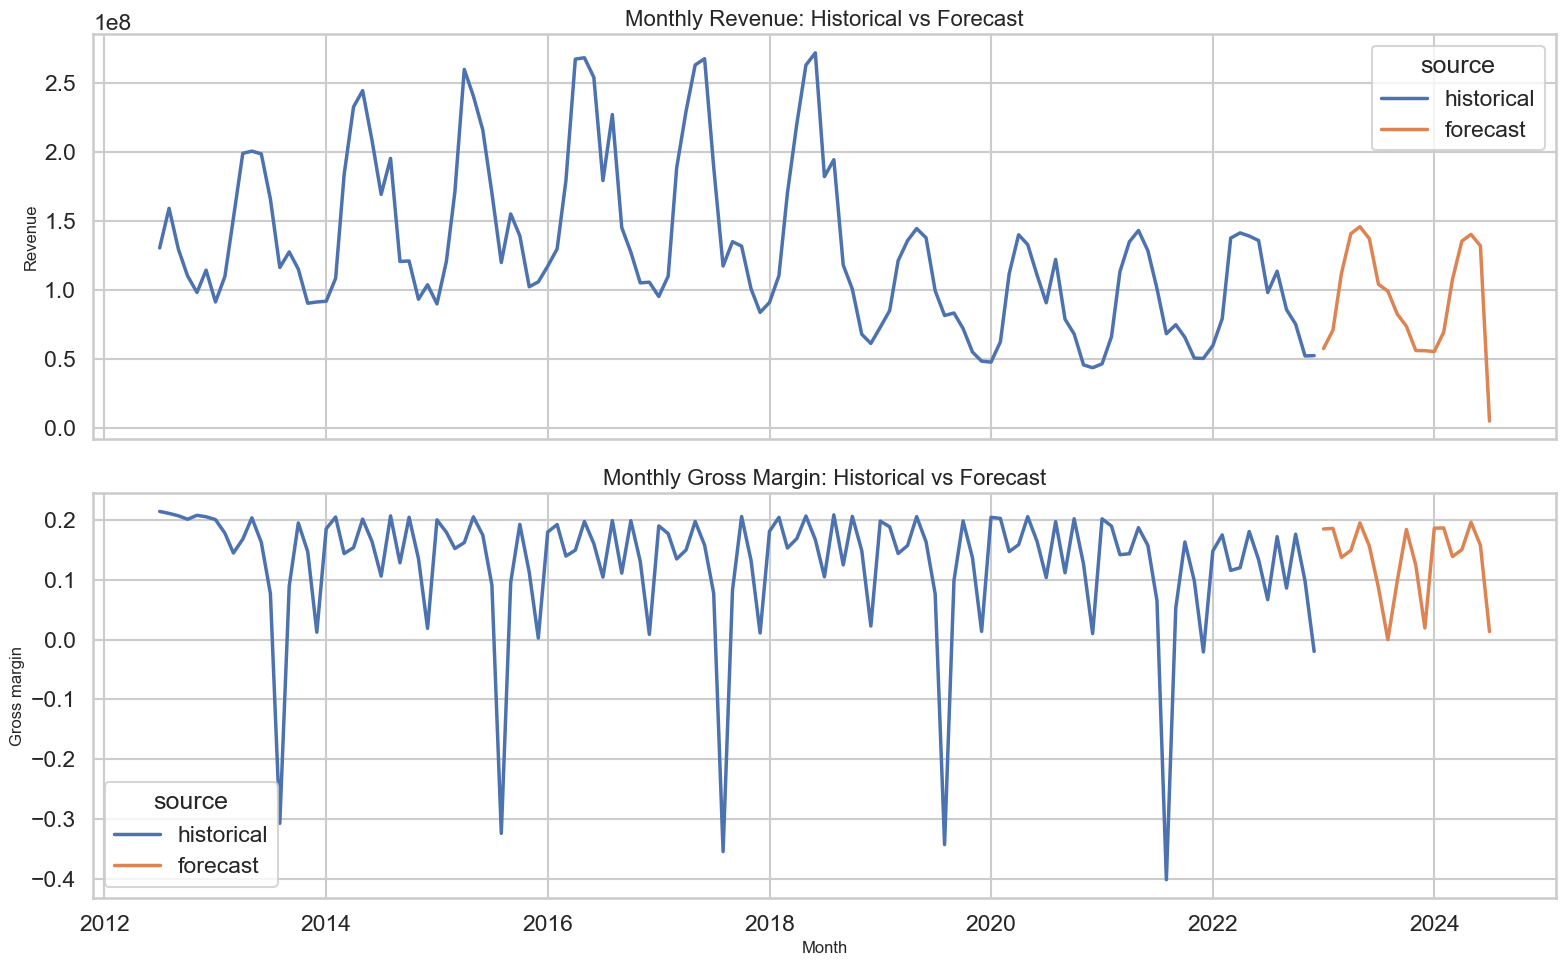

,month,source,revenue,cogs,gross_margin
120,2022-07-01,historical,9.814178e+07,91605928.72,0.066596
121,2022-08-01,historical,1.135429e+08,94033378.34,0.171825
122,2022-09-01,historical,8.576429e+07,78395242.27,0.085922
123,2022-10-01,historical,7.519445e+07,61969893.80,0.175871
124,2022-11-01,historical,5.220008e+07,47098021.50,0.097740
125,2022-12-01,historical,5.245494e+07,53489673.44,-0.019726


,month,source,revenue,cogs,gross_margin
126,2023-01-01,forecast,5.758202e+07,4.695262e+07,0.184596
127,2023-02-01,forecast,7.090553e+07,5.774542e+07,0.185601
128,2023-03-01,forecast,1.119812e+08,9.661496e+07,0.137221
129,2023-04-01,forecast,1.407405e+08,1.198077e+08,0.148733
130,2023-05-01,forecast,1.457801e+08,1.173947e+08,0.194714
131,2023-06-01,forecast,1.371266e+08,1.157188e+08,0.156117


In [12]:
sales_hist = sales.rename(columns={"Date": "date", "Revenue": "revenue", "COGS": "cogs"}).copy()
sales_hist["source"] = "historical"
sales_hist["gross_margin"] = (sales_hist["revenue"] - sales_hist["cogs"]) / sales_hist["revenue"]

sales_fc = sample_submission.rename(columns={"Date": "date", "Revenue": "revenue", "COGS": "cogs"}).copy()
sales_fc["source"] = "forecast"
sales_fc["gross_margin"] = (sales_fc["revenue"] - sales_fc["cogs"]) / sales_fc["revenue"]

sales_all = pd.concat([sales_hist, sales_fc], ignore_index=True)
monthly_sales = sales_all.assign(month=sales_all["date"].dt.to_period("M").dt.to_timestamp()).groupby(["month", "source"], as_index=False).agg(
    revenue=("revenue", "sum"),
    cogs=("cogs", "sum"),
)
monthly_sales["gross_margin"] = (monthly_sales["revenue"] - monthly_sales["cogs"]) / monthly_sales["revenue"]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
sns.lineplot(data=monthly_sales, x="month", y="revenue", hue="source", ax=axes[0], linewidth=2.5)
axes[0].set_title("Monthly Revenue: Historical vs Forecast")
axes[0].set_ylabel("Revenue")
axes[0].set_xlabel("")

sns.lineplot(data=monthly_sales, x="month", y="gross_margin", hue="source", ax=axes[1], linewidth=2.5)
axes[1].set_title("Monthly Gross Margin: Historical vs Forecast")
axes[1].set_ylabel("Gross margin")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

hist_tail = monthly_sales[monthly_sales["source"] == "historical"].tail(6)
fc_head = monthly_sales[monthly_sales["source"] == "forecast"].head(6)

display(hist_tail)
display(fc_head)

**Phân tích & hàm ý kinh doanh**

- Nếu quỹ đạo forecast cho thấy doanh thu tăng nhanh hơn COGS, doanh nghiệp có dư địa mở rộng đầu tư tăng trưởng.
- Nếu biên dự báo co hẹp, cần ưu tiên can thiệp vào mix sản phẩm, chính sách khuyến mãi và chi phí fulfillment.
- Khuyến nghị: theo dõi “early warning” theo tuần cho gross margin để phản ứng sớm trước biến động chi phí.

## 10) Prescriptive — Action Playbook (ưu tiên triển khai)

Bảng dưới đây tổng hợp hành động dựa trên các insight ở trên, đi kèm KPI theo dõi và tác động kỳ vọng.

In [13]:
top_return_reason = returns["return_reason"].value_counts().index[0]
best_source = efficiency.sort_values("orders_per_1k_sessions", ascending=False).iloc[0]["traffic_source"]
worst_delivery_region = ship_summary.sort_values("avg_delivery_days", ascending=False).iloc[0]["region"]
worst_stockout_segment = inv_latest.sort_values("stockout_rate", ascending=False).iloc[0]["segment"]

playbook = pd.DataFrame([
    {
        "Priority": 1,
        "Focus": "Giảm hoàn trả theo sản phẩm",
        "Action": f"Rà soát SKU thuộc nhóm return cao; ưu tiên xử lý lý do phổ biến nhất: {top_return_reason}",
        "KPI": "Return rate, Refund amount, Rating",
        "Expected_impact": "Giảm chi phí hoàn trả, cải thiện biên lợi nhuận"
    },
    {
        "Priority": 2,
        "Focus": "Tối ưu ngân sách traffic",
        "Action": f"Tăng ngân sách cho nguồn hiệu quả cao ({best_source}); A/B test landing cho nguồn bounce cao",
        "KPI": "Orders/1k sessions, Bounce rate, CAC proxy",
        "Expected_impact": "Tăng đơn hàng trên cùng mức traffic"
    },
    {
        "Priority": 3,
        "Focus": "Nâng hiệu suất giao hàng",
        "Action": f"Thiết kế SLA vận chuyển riêng cho vùng {worst_delivery_region} có lead time cao",
        "KPI": "Delivery days p50/p90, Late-delivery returns",
        "Expected_impact": "Giảm huỷ/hoàn do giao trễ"
    },
    {
        "Priority": 4,
        "Focus": "Kiểm soát tồn kho thông minh",
        "Action": f"Thiết lập safety stock theo segment, ưu tiên {worst_stockout_segment}",
        "KPI": "Stockout rate, Fill rate, Sell-through",
        "Expected_impact": "Giảm mất doanh thu do thiếu hàng"
    },
])

display(playbook)

print("Kết luận: Bộ chỉ số trên tạo thành vòng lặp quản trị Growth + Profit + Service Level.")

,Priority,Focus,Action,KPI,Expected_impact
0,1,Giảm hoàn trả theo sản phẩm,Rà soát SKU thuộc nhóm return cao; ưu tiên xử ...,"Return rate, Refund amount, Rating","Giảm chi phí hoàn trả, cải thiện biên lợi nhuận"
1,2,Tối ưu ngân sách traffic,Tăng ngân sách cho nguồn hiệu quả cao (social_...,"Orders/1k sessions, Bounce rate, CAC proxy",Tăng đơn hàng trên cùng mức traffic
2,3,Nâng hiệu suất giao hàng,Thiết kế SLA vận chuyển riêng cho vùng West có...,"Delivery days p50/p90, Late-delivery returns",Giảm huỷ/hoàn do giao trễ
3,4,Kiểm soát tồn kho thông minh,"Thiết lập safety stock theo segment, ưu tiên A...","Stockout rate, Fill rate, Sell-through",Giảm mất doanh thu do thiếu hàng


Kết luận: Bộ chỉ số trên tạo thành vòng lặp quản trị Growth + Profit + Service Level.


## 11) Key Findings định lượng (tóm tắt cho báo cáo)

Cell dưới đây tự động tổng hợp các phát hiện quan trọng bằng số liệu cụ thể, thuận tiện đưa vào slide/thuyết trình.

In [14]:
best_source_row = efficiency.sort_values("orders_per_1k_sessions", ascending=False).iloc[0]
worst_source_row = efficiency.sort_values("orders_per_1k_sessions", ascending=True).iloc[0]

promo_no = promo_analysis[promo_analysis["promo_applied"] == False].iloc[0]
promo_yes = promo_analysis[promo_analysis["promo_applied"] == True].iloc[0]

worst_return_row = cat_quality.sort_values("return_rate", ascending=False).iloc[0]

hist_2022_margin = monthly_sales[(monthly_sales["source"] == "historical") & (monthly_sales["month"].dt.year == 2022)]["gross_margin"].mean()
fc_2023_margin = monthly_sales[(monthly_sales["source"] == "forecast") & (monthly_sales["month"].dt.year == 2023)]["gross_margin"].mean()

print("=== KEY FINDINGS (ĐỊNH LƯỢNG) ===")
print(f"1) Quy mô: {total_orders:,.0f} đơn | {total_customers:,.0f} khách | Net revenue {net_revenue_total:,.0f} | Gross margin tổng {gross_margin_total:.2%}.")
print(f"2) Traffic: nguồn hiệu quả nhất là {best_source_row['traffic_source']} ({best_source_row['orders_per_1k_sessions']:.2f} đơn/1k sessions); thấp nhất là {worst_source_row['traffic_source']} ({worst_source_row['orders_per_1k_sessions']:.2f}).")
print(f"3) Promo: margin không promo = {promo_no['gross_margin']:.2%}, có promo = {promo_yes['gross_margin']:.2%} (chênh {promo_yes['gross_margin']-promo_no['gross_margin']:.2%}).")
print(f"4) Chất lượng: nhóm return cao nhất là {worst_return_row['category']}|{worst_return_row['segment']} ({worst_return_row['return_rate']:.2%}), rating TB {worst_return_row['avg_rating']:.2f}.")
print(f"5) Logistics: vùng lead time cao nhất là {worst_delivery_region} ({ship_summary['avg_delivery_days'].max():.2f} ngày trung bình).")
print(f"6) Inventory: segment stockout cao nhất gần nhất là {worst_stockout_segment} ({inv_latest['stockout_rate'].max():.2%}).")
print(f"7) Forecast: gross margin TB 2022 (historical) = {hist_2022_margin:.2%}; 2023 (forecast) = {fc_2023_margin:.2%}.")

=== KEY FINDINGS (ĐỊNH LƯỢNG) ===
1) Quy mô: 646,945 đơn | 121,930 khách | Net revenue 15,680,869,265 | Gross margin tổng 9.68%.
2) Traffic: nguồn hiệu quả nhất là social_media (8.20 đơn/1k sessions); thấp nhất là email_campaign (6.06).
3) Promo: margin không promo = 19.96%, có promo = -14.46% (chênh -34.42%).
4) Chất lượng: nhóm return cao nhất là Casual|Activewear (6.12%), rating TB 3.86.
5) Logistics: vùng lead time cao nhất là West (4.50 ngày trung bình).
6) Inventory: segment stockout cao nhất gần nhất là All-weather (76.32%).
7) Forecast: gross margin TB 2022 (historical) = 12.08%; 2023 (forecast) = 12.66%.


## 12) Advanced Business-Focused Insights (thêm 10 biểu đồ)

Phần này bổ sung các mối quan hệ mà doanh nghiệp thường quan tâm: **Pareto doanh thu, tối ưu biên lợi nhuận, hiệu quả giảm giá, hành vi thanh toán, vận hành giao hàng, retention, và rủi ro hoàn trả**.

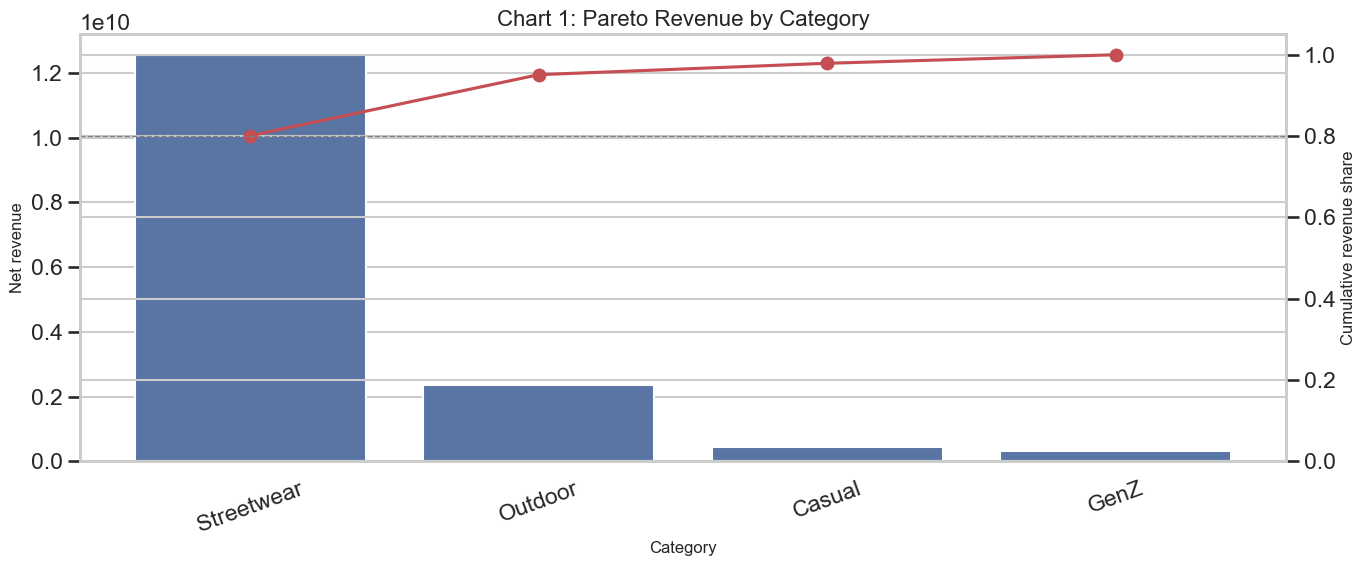

Top 2 categories đóng góp ~95.10% doanh thu.


In [15]:
# Chart 1 — Pareto doanh thu theo category
cat_rev = line_items.groupby("category", as_index=False).agg(revenue=("net_revenue", "sum")).sort_values("revenue", ascending=False)
cat_rev["cum_share"] = cat_rev["revenue"].cumsum() / cat_rev["revenue"].sum()

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=cat_rev, x="category", y="revenue", ax=ax1, color="#4C72B0")
ax1.set_title("Chart 1: Pareto Revenue by Category")
ax1.set_xlabel("Category")
ax1.set_ylabel("Net revenue")
ax1.tick_params(axis="x", rotation=20)

ax2 = ax1.twinx()
ax2.plot(range(len(cat_rev)), cat_rev["cum_share"], color="#C44E52", marker="o")
ax2.axhline(0.8, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative revenue share")
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

top2_share = cat_rev["cum_share"].iloc[min(1, len(cat_rev)-1)]
print(f"Top 2 categories đóng góp ~{top2_share:.2%} doanh thu.")

**Phân tích Chart 1**

- **Ý nghĩa**: Xác định mức độ tập trung doanh thu để tránh phụ thuộc vào một vài ngành hàng.
- **Key finding**: Dùng tỷ lệ cộng dồn để kiểm tra quy tắc 80/20.
- **Action**: Nếu tập trung quá cao, cần đa dạng hóa category và xây kế hoạch phòng ngừa rủi ro nguồn cung.

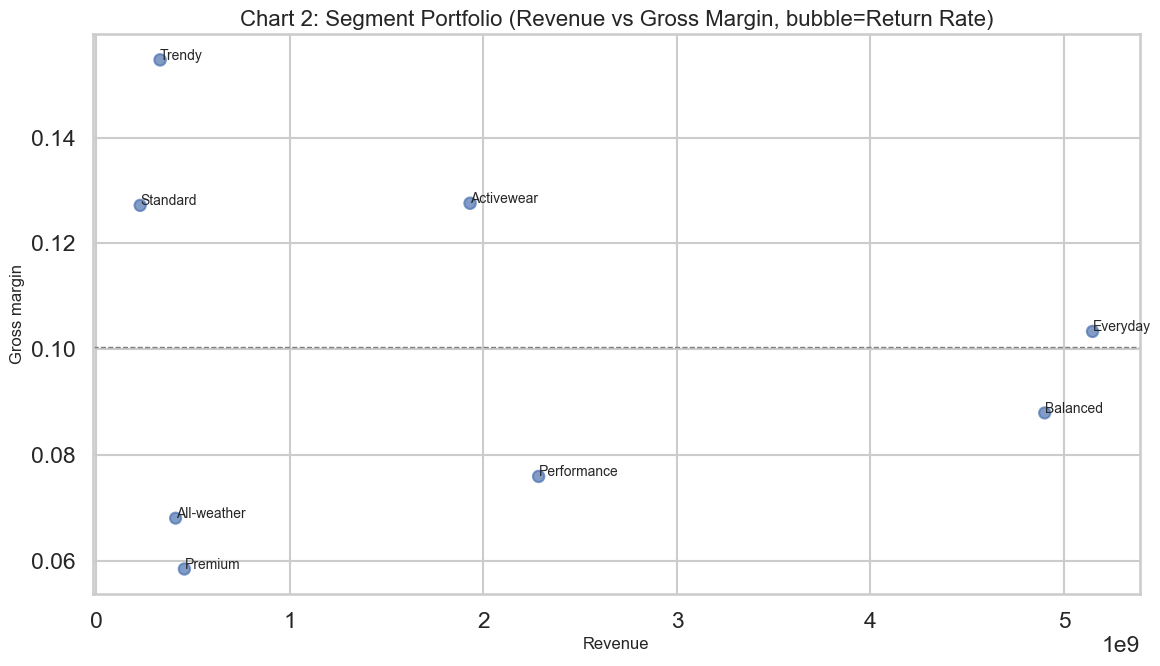

,segment,revenue,gross_profit,return_rate,gross_margin
3,Everyday,5.147455e+09,5.321748e+08,0.055568,0.103386
2,Balanced,4.900318e+09,4.312361e+08,0.054320,0.088002
4,Performance,2.285029e+09,1.736938e+08,0.056260,0.076014
0,Activewear,1.930705e+09,2.463395e+08,0.056799,0.127590
5,Premium,4.542119e+08,2.658623e+07,0.055491,0.058533
1,All-weather,4.087651e+08,2.784908e+07,0.053478,0.068130
7,Trendy,3.287102e+08,5.083638e+07,0.057214,0.154654
6,Standard,2.256749e+08,2.870285e+07,0.054951,0.127187


In [16]:
# Chart 2 — Segment revenue vs gross margin (portfolio map)
seg_perf = line_items.groupby("segment", as_index=False).agg(
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    return_rate=("is_returned", "mean")
)
seg_perf["gross_margin"] = seg_perf["gross_profit"] / seg_perf["revenue"]

plt.figure(figsize=(12, 7))
plt.scatter(seg_perf["revenue"], seg_perf["gross_margin"], s=1200*seg_perf["return_rate"], alpha=0.7)
for _, r in seg_perf.iterrows():
    plt.annotate(r["segment"], (r["revenue"], r["gross_margin"]), fontsize=10)

plt.title("Chart 2: Segment Portfolio (Revenue vs Gross Margin, bubble=Return Rate)")
plt.xlabel("Revenue")
plt.ylabel("Gross margin")
plt.axhline(seg_perf["gross_margin"].mean(), color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

display(seg_perf.sort_values("revenue", ascending=False))

**Phân tích Chart 2**

- **Ý nghĩa**: Giúp phân bổ ngân sách theo segment dựa trên 3 yếu tố: quy mô, biên lợi nhuận, rủi ro hoàn trả.
- **Key finding**: Bubble lớn ở vùng margin thấp là khu vực “doanh thu cao nhưng chất lượng lợi nhuận kém”.
- **Action**: Ưu tiên tối ưu giá/chi phí cho segment doanh thu cao, đồng thời giảm return rate bằng cải thiện sản phẩm.

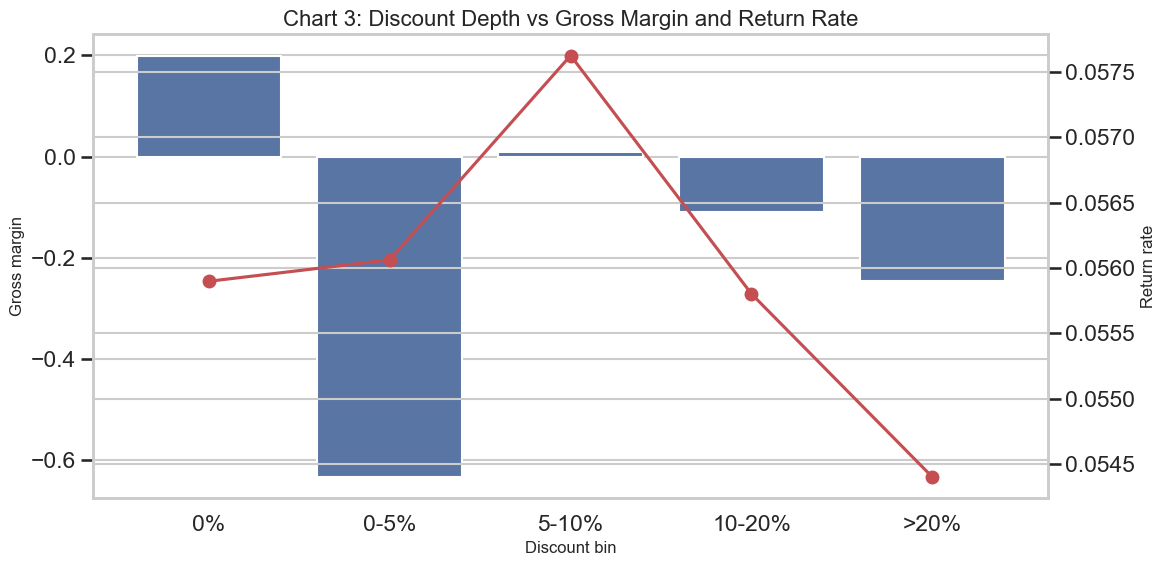

,discount_bin,lines,gross_margin,return_rate
0,0%,438353,0.199637,0.055898
1,0-5%,20852,-0.632791,0.056062
2,5-10%,26378,0.008735,0.057624
3,10-20%,203186,-0.108491,0.055801
4,>20%,25900,-0.245586,0.054402


In [17]:
# Chart 3 — Discount depth vs margin và return rate
x = line_items.copy()
x = x[x["gross_revenue"] > 0].copy()
x["discount_pct"] = (x["discount_amount"].fillna(0) / x["gross_revenue"]).clip(0, 1)
x["discount_bin"] = pd.cut(x["discount_pct"], bins=[-0.001, 0, 0.05, 0.1, 0.2, 1], labels=["0%", "0-5%", "5-10%", "10-20%", ">20%"])

disc = x.groupby("discount_bin", as_index=False).agg(
    lines=("order_id", "count"),
    gross_margin=("gross_profit", lambda s: s.sum() / x.loc[s.index, "net_revenue"].sum() if x.loc[s.index, "net_revenue"].sum() else np.nan),
    return_rate=("is_returned", "mean")
)

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=disc, x="discount_bin", y="gross_margin", ax=ax1, color="#4C72B0")
ax1.set_title("Chart 3: Discount Depth vs Gross Margin and Return Rate")
ax1.set_xlabel("Discount bin")
ax1.set_ylabel("Gross margin")

ax2 = ax1.twinx()
ax2.plot(range(len(disc)), disc["return_rate"], color="#C44E52", marker="o")
ax2.set_ylabel("Return rate")

plt.tight_layout()
plt.show()
display(disc)

**Phân tích Chart 3**

- **Ý nghĩa**: Trả lời câu hỏi “giảm giá thêm có còn hiệu quả không?”.
- **Key finding**: Nếu margin giảm nhanh hơn tốc độ cải thiện chuyển đổi, mức discount đó không bền vững.
- **Action**: Đặt trần discount theo category/segment và theo dõi lợi nhuận tuyệt đối thay vì chỉ doanh thu.

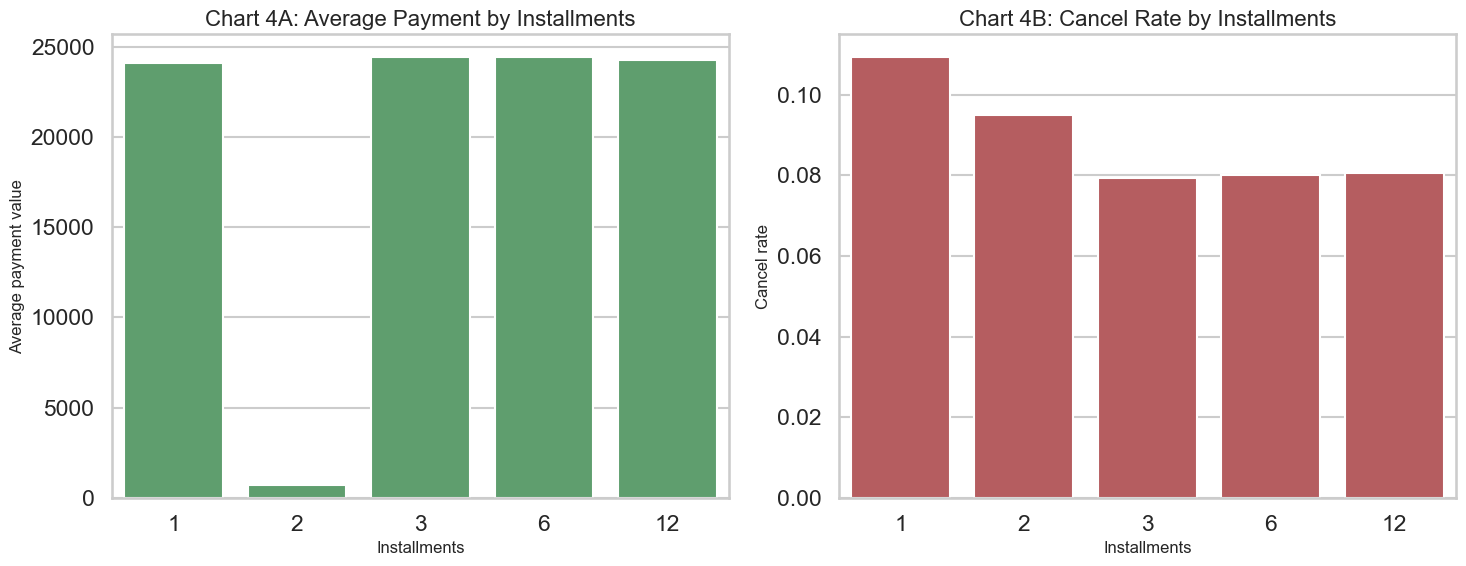

,installments,orders,avg_payment,cancel_rate
0,1,262866,24113.274166,0.109508
2,3,218949,24399.635486,0.079429
3,6,109910,24446.654403,0.080184
4,12,54126,24245.772694,0.080701
1,2,1094,708.473729,0.095064


In [18]:
# Chart 4 — Installments vs AOV và cancellation
inst = orders_master.groupby("installments", as_index=False).agg(
    orders=("order_id", "nunique"),
    avg_payment=("payment_value", "mean"),
    cancel_rate=("order_status", lambda s: (s == "cancelled").mean())
).dropna(subset=["installments"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=inst, x="installments", y="avg_payment", ax=axes[0], color="#55A868")
axes[0].set_title("Chart 4A: Average Payment by Installments")
axes[0].set_xlabel("Installments")
axes[0].set_ylabel("Average payment value")

sns.barplot(data=inst, x="installments", y="cancel_rate", ax=axes[1], color="#C44E52")
axes[1].set_title("Chart 4B: Cancel Rate by Installments")
axes[1].set_xlabel("Installments")
axes[1].set_ylabel("Cancel rate")

plt.tight_layout()
plt.show()
display(inst.sort_values("orders", ascending=False))

**Phân tích Chart 4**

- **Ý nghĩa**: Trả góp giúp tăng khả năng mua nhưng có thể kéo theo rủi ro huỷ.
- **Key finding**: So sánh đồng thời `avg_payment` và `cancel_rate` theo kỳ trả góp để tìm mức tối ưu.
- **Action**: Giới hạn kỳ trả góp dài cho nhóm rủi ro cao, hoặc thêm điều kiện xác thực trước khi duyệt đơn.

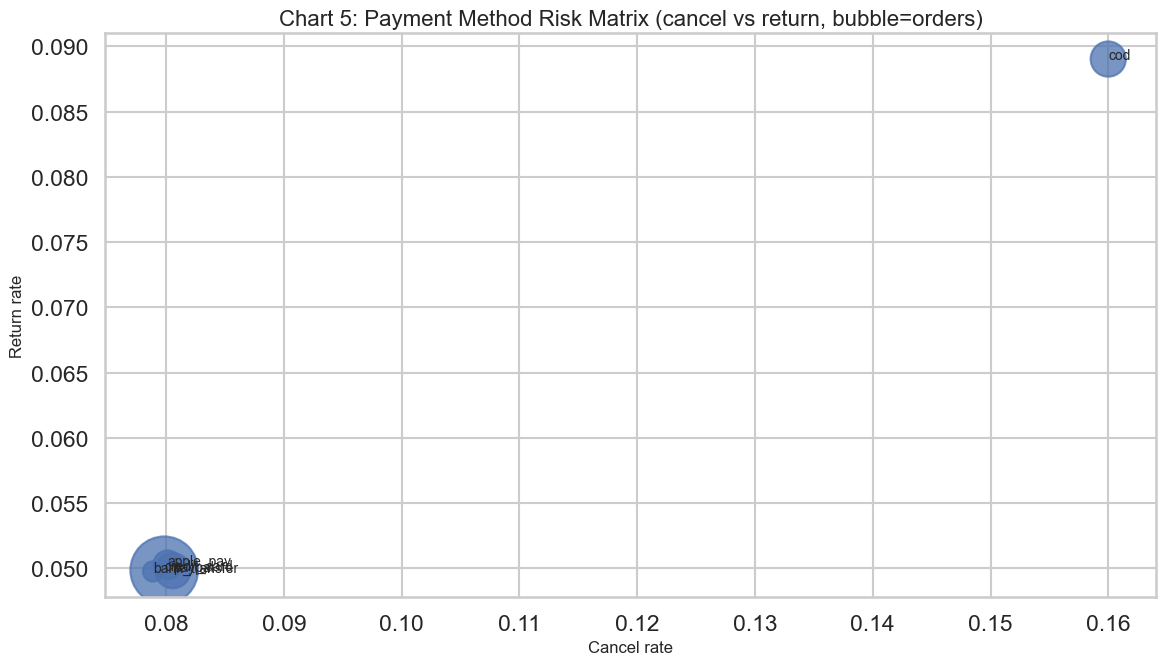

,payment_method,orders,cancel_rate,avg_payment,return_rate
3,credit_card,356352,0.079842,24217.822303,0.049855
4,paypal,97018,0.080573,24363.315444,0.049826
2,cod,96681,0.159990,24275.168781,0.089025
0,apple_pay,64763,0.080138,24153.754621,0.050276
1,bank_transfer,32131,0.078896,24148.097198,0.049765


In [19]:
# Chart 5 — Payment method risk matrix
pay_risk = orders_master.groupby("payment_method", as_index=False).agg(
    orders=("order_id", "nunique"),
    cancel_rate=("order_status", lambda s: (s == "cancelled").mean()),
    avg_payment=("payment_value", "mean")
)

ret_by_order = line_items.groupby("order_id", as_index=False).agg(returned=("is_returned", "max"))
pay_risk = pay_risk.merge(orders_master[["order_id", "payment_method"]].merge(ret_by_order, on="order_id", how="left").groupby("payment_method", as_index=False)["returned"].mean().rename(columns={"returned": "return_rate"}), on="payment_method", how="left")

plt.figure(figsize=(12, 7))
plt.scatter(pay_risk["cancel_rate"], pay_risk["return_rate"], s=pay_risk["orders"]/150, alpha=0.75)
for _, r in pay_risk.iterrows():
    plt.annotate(r["payment_method"], (r["cancel_rate"], r["return_rate"]), fontsize=10)
plt.title("Chart 5: Payment Method Risk Matrix (cancel vs return, bubble=orders)")
plt.xlabel("Cancel rate")
plt.ylabel("Return rate")
plt.tight_layout()
plt.show()

display(pay_risk.sort_values("orders", ascending=False))

**Phân tích Chart 5**

- **Ý nghĩa**: Một số phương thức thanh toán có thể kéo theo rủi ro huỷ/hoàn cao.
- **Key finding**: Bubble lớn nằm ở góc trên-phải (huỷ cao + hoàn cao) là vùng cần kiểm soát fraud/chất lượng đơn.
- **Action**: Áp chính sách xác minh bổ sung hoặc điều chỉnh ưu đãi theo payment method.

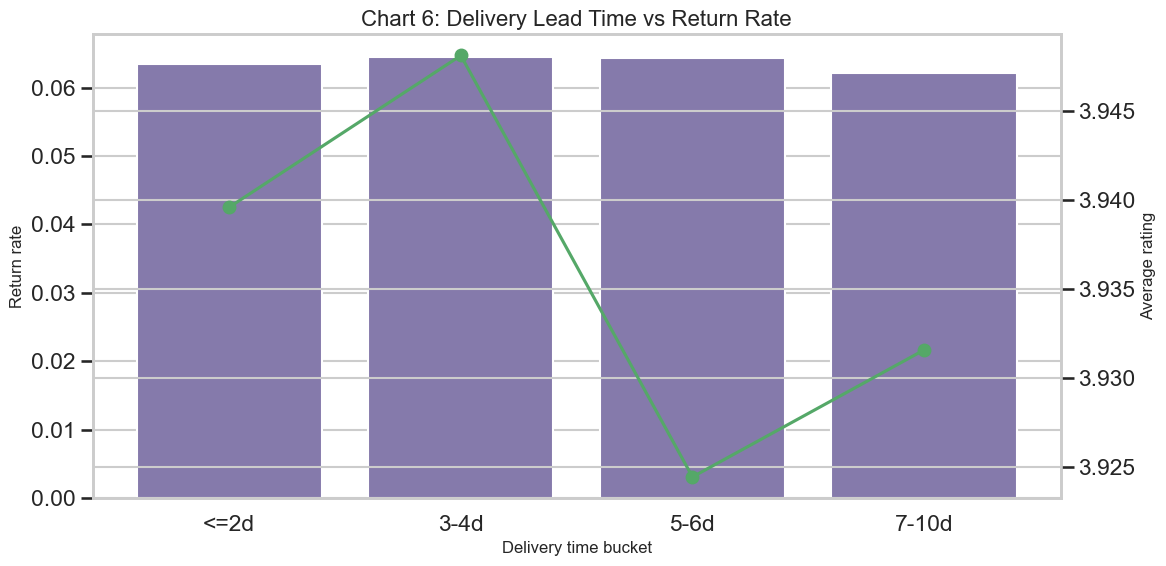

,delivery_bucket,lines,return_rate,avg_rating
0,<=2d,104194,0.063497,3.939600
1,3-4d,208608,0.064533,3.948111
2,5-6d,208585,0.064247,3.924470
3,7-10d,103995,0.062118,3.931593


In [20]:
# Chart 6 — Delivery lead time bucket vs return rate
lead = line_items.dropna(subset=["delivery_days"]).copy()
lead["delivery_bucket"] = pd.cut(lead["delivery_days"], bins=[-1, 2, 4, 6, 10, 30], labels=["<=2d", "3-4d", "5-6d", "7-10d", ">10d"])
lead_perf = lead.groupby("delivery_bucket", as_index=False).agg(
    lines=("order_id", "count"),
    return_rate=("is_returned", "mean"),
    avg_rating=("avg_rating", "mean")
)

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=lead_perf, x="delivery_bucket", y="return_rate", ax=ax1, color="#8172B3")
ax1.set_title("Chart 6: Delivery Lead Time vs Return Rate")
ax1.set_xlabel("Delivery time bucket")
ax1.set_ylabel("Return rate")

ax2 = ax1.twinx()
ax2.plot(range(len(lead_perf)), lead_perf["avg_rating"], color="#55A868", marker="o")
ax2.set_ylabel("Average rating")

plt.tight_layout()
plt.show()
display(lead_perf)

**Phân tích Chart 6**

- **Ý nghĩa**: Tốc độ giao hàng ảnh hưởng trực tiếp đến trải nghiệm và chi phí hoàn trả.
- **Key finding**: Bucket giao chậm có thể đồng thời return cao và rating thấp.
- **Action**: Ưu tiên cải thiện SLA cho bucket xấu nhất, theo dõi lại sau mỗi 2-4 tuần.

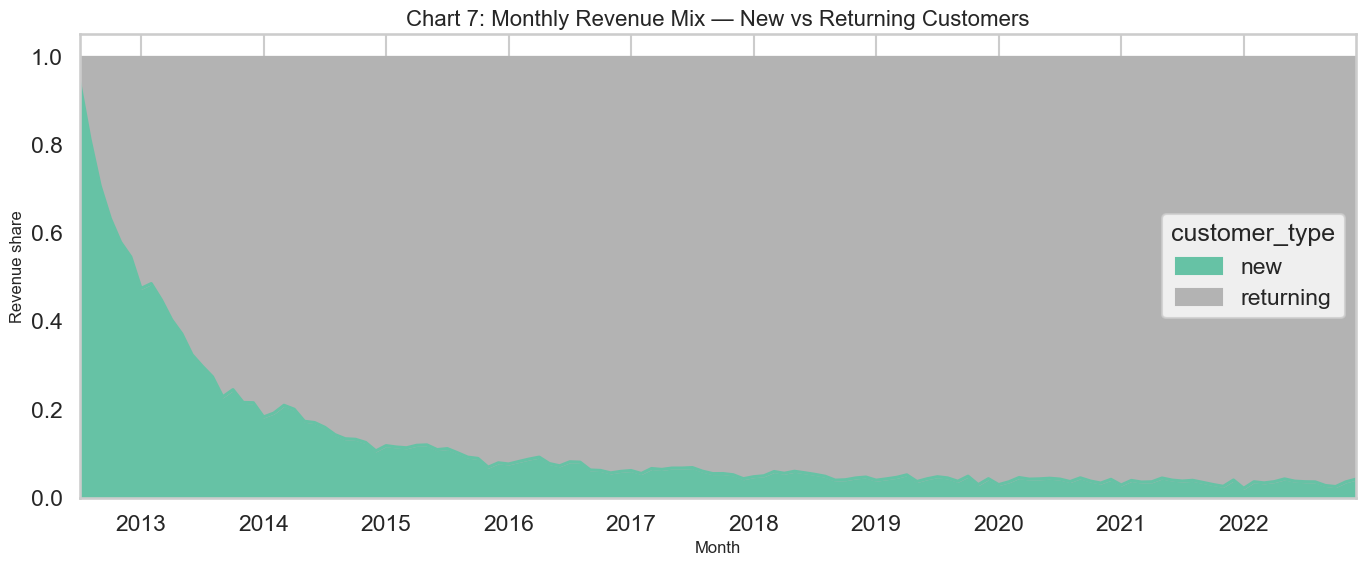

customer_type,new,returning
order_month,,
2022-01-01,0.022122,0.977878
2022-02-01,0.037016,0.962984
2022-03-01,0.034402,0.965598
2022-04-01,0.037228,0.962772
2022-05-01,0.043420,0.956580
2022-06-01,0.038361,0.961639
2022-07-01,0.037092,0.962908
2022-08-01,0.036723,0.963277
2022-09-01,0.028544,0.971456


In [21]:
# Chart 7 — New vs returning customer revenue mix theo tháng
first_order_date = orders.groupby("customer_id", as_index=False)["order_date"].min().rename(columns={"order_date": "first_order_date"})
ord_type = orders[["order_id", "customer_id", "order_date"]].merge(first_order_date, on="customer_id", how="left")
ord_type["customer_type"] = np.where(ord_type["order_date"] == ord_type["first_order_date"], "new", "returning")

mix = line_items[["order_id", "order_month", "net_revenue"]].merge(ord_type[["order_id", "customer_type"]], on="order_id", how="left")
mix_m = mix.groupby(["order_month", "customer_type"], as_index=False)["net_revenue"].sum()

pivot_mix = mix_m.pivot(index="order_month", columns="customer_type", values="net_revenue").fillna(0)
pivot_share = pivot_mix.div(pivot_mix.sum(axis=1), axis=0)

pivot_share.plot(kind="area", stacked=True, figsize=(14, 6), colormap="Set2")
plt.title("Chart 7: Monthly Revenue Mix — New vs Returning Customers")
plt.xlabel("Month")
plt.ylabel("Revenue share")
plt.tight_layout()
plt.show()

display(pivot_share.tail(12))

**Phân tích Chart 7**

- **Ý nghĩa**: Tăng trưởng bền vững cần tỷ trọng doanh thu từ khách quay lại ổn định/tăng dần.
- **Key finding**: Nếu doanh thu phụ thuộc quá mạnh vào khách mới, chi phí acquisition sẽ tạo áp lực lợi nhuận.
- **Action**: Đẩy CRM/loyalty cho cohort có dấu hiệu giảm quay lại.

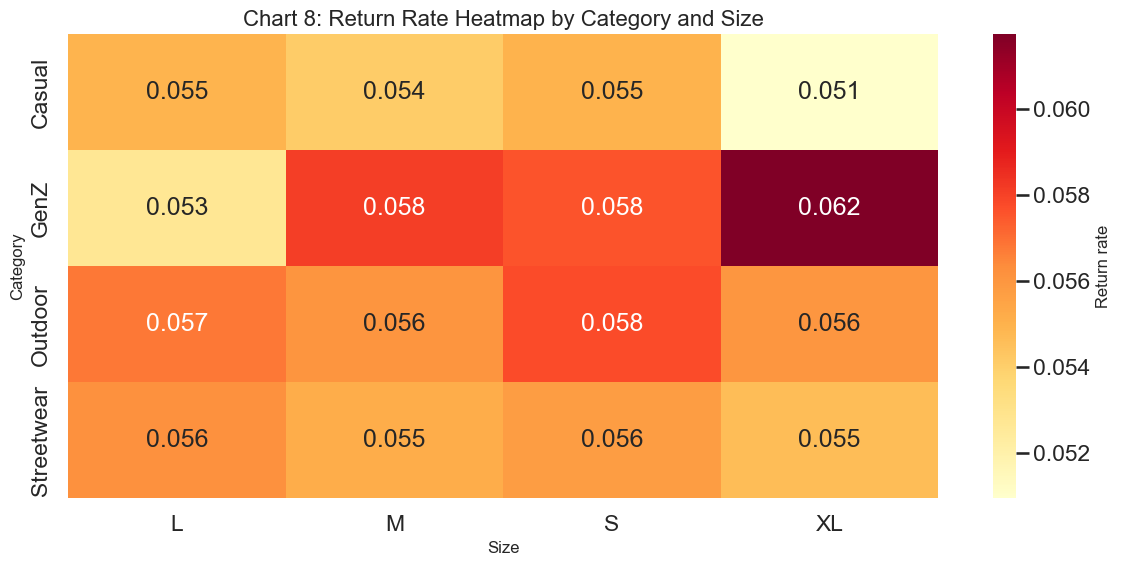

,category,size,lines,return_rate
7,GenZ,XL,5393,0.061747
5,GenZ,M,10275,0.058102
10,Outdoor,S,55596,0.057756
6,GenZ,S,12899,0.057601
8,Outdoor,L,72086,0.056779
12,Streetwear,L,88765,0.056216
9,Outdoor,M,70915,0.056067
11,Outdoor,XL,61389,0.056036
14,Streetwear,S,95328,0.055776
13,Streetwear,M,87809,0.055177


In [22]:
# Chart 8 — Heatmap return rate theo size x category
size_cat = line_items.groupby(["category", "size"], as_index=False).agg(
    lines=("order_id", "count"),
    return_rate=("is_returned", "mean")
)
heat_size = size_cat.pivot(index="category", columns="size", values="return_rate")

plt.figure(figsize=(12, 6))
sns.heatmap(heat_size, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={"label": "Return rate"})
plt.title("Chart 8: Return Rate Heatmap by Category and Size")
plt.xlabel("Size")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

display(size_cat.sort_values("return_rate", ascending=False).head(12))

**Phân tích Chart 8**

- **Ý nghĩa**: Return theo size là vấn đề điển hình trong bán lẻ thời trang.
- **Key finding**: Các ô “nóng” chỉ ra cặp `category-size` cần can thiệp size chart và nội dung mô tả.
- **Action**: A/B test bảng size mới và theo dõi giảm return theo từng category-size.

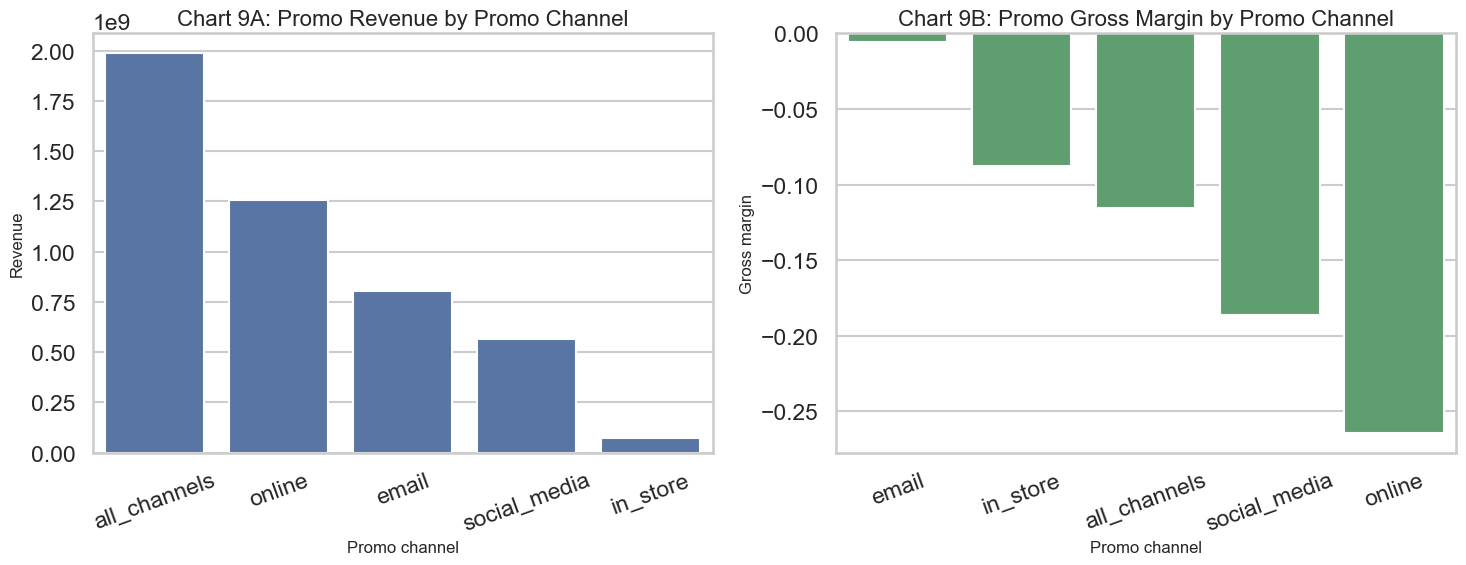

,promo_channel,lines,revenue,gross_profit,return_rate,gross_margin
0,all_channels,127687,1.986129e+09,-2.292681e+08,0.055331,-0.115435
3,online,66171,1.258133e+09,-3.323598e+08,0.055281,-0.264169
1,email,41576,8.036246e+08,-4.337054e+06,0.057894,-0.005397
4,social_media,31977,5.651188e+08,-1.052566e+08,0.054539,-0.186256
2,in_store,8905,7.282432e+07,-6.375165e+06,0.063111,-0.087542


In [23]:
# Chart 9 — Promo channel effectiveness
promo_ch = line_items[line_items["promo_applied"]].groupby("promo_channel", as_index=False).agg(
    lines=("order_id", "count"),
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    return_rate=("is_returned", "mean")
)
promo_ch["gross_margin"] = promo_ch["gross_profit"] / promo_ch["revenue"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=promo_ch.sort_values("revenue", ascending=False), x="promo_channel", y="revenue", ax=axes[0], color="#4C72B0")
axes[0].set_title("Chart 9A: Promo Revenue by Promo Channel")
axes[0].set_xlabel("Promo channel")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=promo_ch.sort_values("gross_margin", ascending=False), x="promo_channel", y="gross_margin", ax=axes[1], color="#55A868")
axes[1].set_title("Chart 9B: Promo Gross Margin by Promo Channel")
axes[1].set_xlabel("Promo channel")
axes[1].set_ylabel("Gross margin")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(promo_ch.sort_values("revenue", ascending=False))

**Phân tích Chart 9**

- **Ý nghĩa**: Không phải kênh promo nào cũng tạo giá trị tương đương.
- **Key finding**: Kênh có revenue cao nhưng margin thấp cần tối ưu thông điệp và mức ưu đãi.
- **Action**: Chuyển ngân sách sang promo channel có “quality revenue” cao hơn (margin tốt, return thấp).

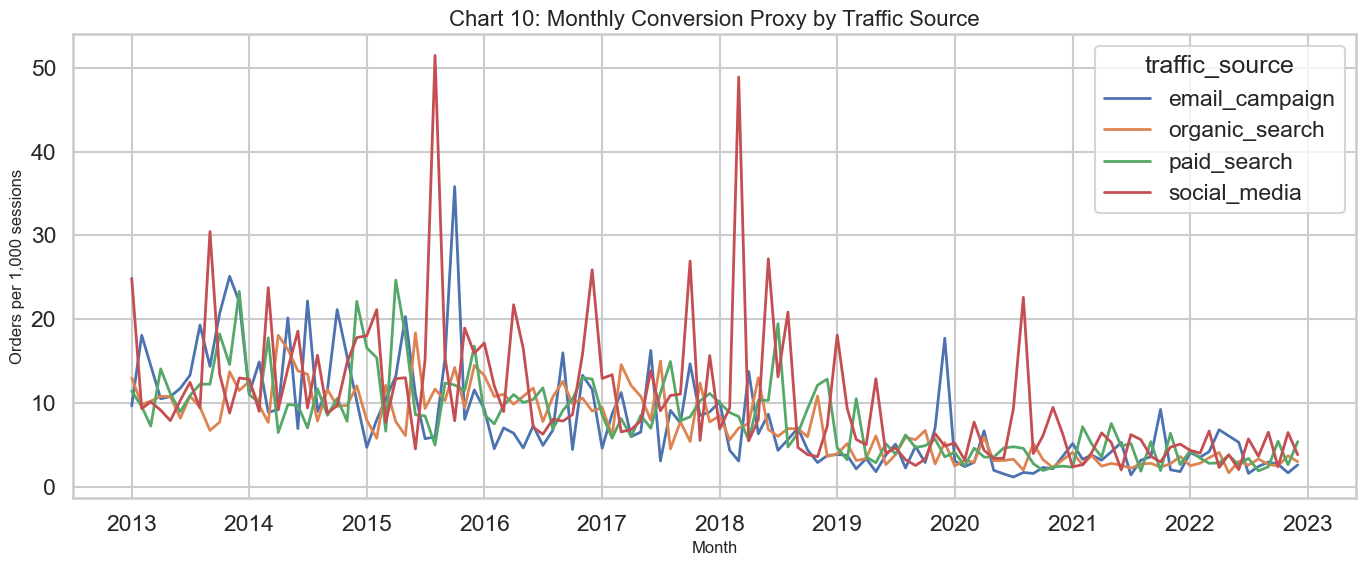

,traffic_source,orders_per_1k_sessions
3,social_media,10.402056
2,paid_search,8.210186
0,email_campaign,7.908373
1,organic_search,7.393663


In [24]:
# Chart 10 — Monthly conversion proxy theo traffic source (orders / sessions)
traffic_m = web_traffic.copy()
traffic_m["month"] = traffic_m["date"].dt.to_period("M").dt.to_timestamp()
traffic_m = traffic_m.groupby(["month", "traffic_source"], as_index=False).agg(sessions=("sessions", "sum"))

orders_m = orders.copy()
orders_m["month"] = orders_m["order_date"].dt.to_period("M").dt.to_timestamp()
orders_m = orders_m.groupby(["month", "order_source"], as_index=False).agg(orders=("order_id", "nunique")).rename(columns={"order_source": "traffic_source"})

conv = traffic_m.merge(orders_m, on=["month", "traffic_source"], how="left")
conv["orders"] = conv["orders"].fillna(0)
conv["orders_per_1k_sessions"] = conv["orders"] / conv["sessions"] * 1000

top_src = conv.groupby("traffic_source")["orders"].sum().sort_values(ascending=False).head(4).index
conv_top = conv[conv["traffic_source"].isin(top_src)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=conv_top, x="month", y="orders_per_1k_sessions", hue="traffic_source", linewidth=2)
plt.title("Chart 10: Monthly Conversion Proxy by Traffic Source")
plt.xlabel("Month")
plt.ylabel("Orders per 1,000 sessions")
plt.tight_layout()
plt.show()

display(conv_top.groupby("traffic_source", as_index=False)["orders_per_1k_sessions"].mean().sort_values("orders_per_1k_sessions", ascending=False))

**Phân tích Chart 10**

- **Ý nghĩa**: Theo dõi hiệu quả marketing theo thời gian thay vì nhìn snapshot 1 kỳ.
- **Key finding**: Nguồn có xu hướng giảm `orders_per_1k_sessions` liên tục cần can thiệp sớm.
- **Action**: Thiết lập cảnh báo nếu conversion proxy giảm quá ngưỡng trong 2-3 tháng liên tiếp.

## 13) Rubric Booster — Deep-dive để tối đa điểm 60/60

Cụm phân tích này tập trung đúng yêu cầu BGK:
- **Descriptive**: đo chính xác KPI nền.
- **Diagnostic**: tìm nguyên nhân qua mối quan hệ chéo bảng.
- **Predictive**: phát hiện tín hiệu sớm và bất thường.
- **Prescriptive**: mô phỏng hành động có định lượng đánh đổi.

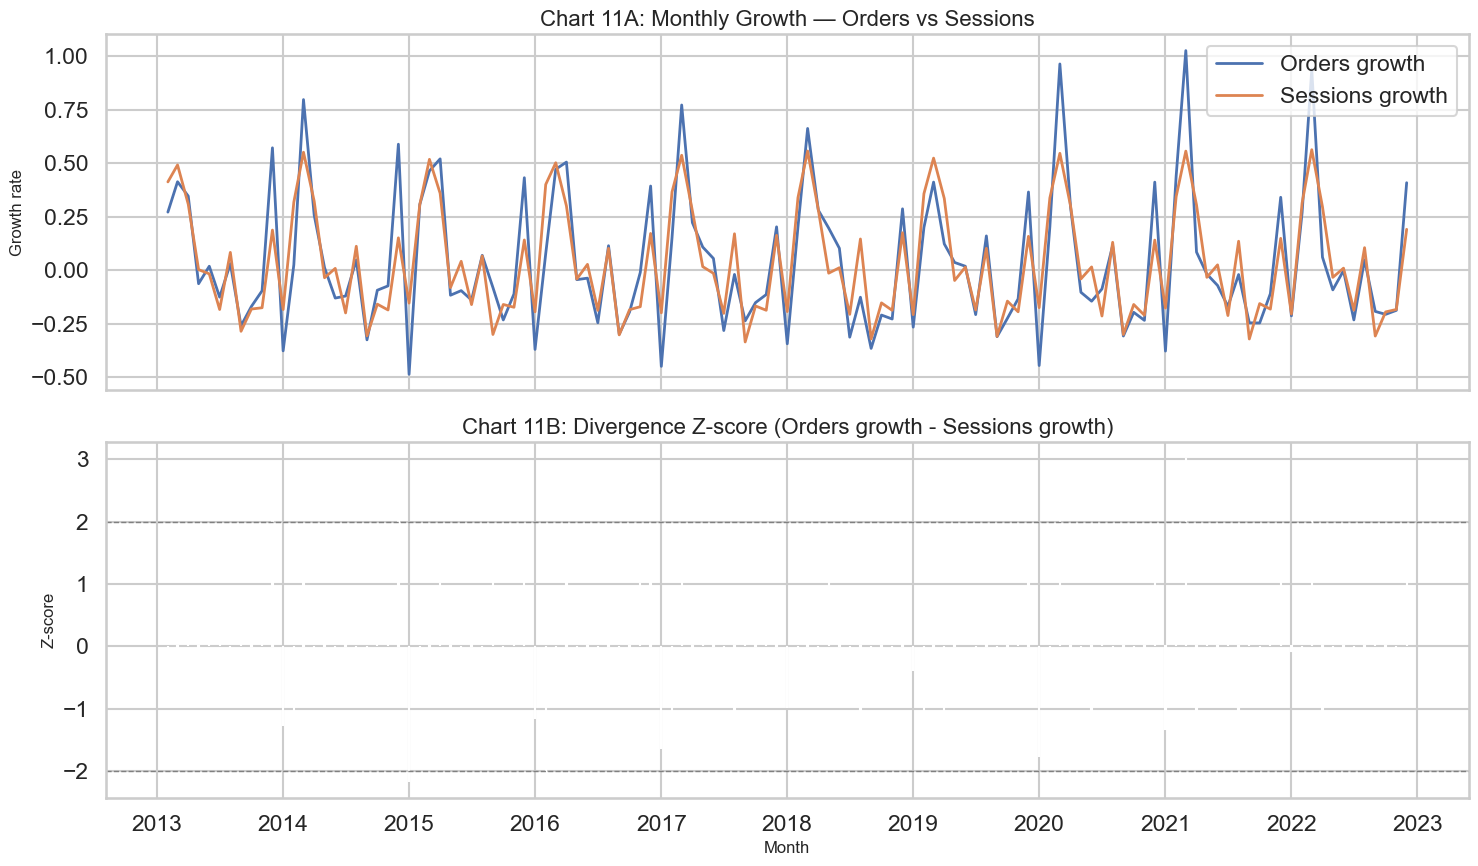

,month,orders_growth,sessions_growth,gap_growth,gap_zscore
98,2021-03-01,1.027328,0.557119,0.470208,3.014067
23,2014-12-01,0.589459,0.151392,0.438068,2.806487
86,2020-03-01,0.964865,0.546823,0.418042,2.677151
11,2013-12-01,0.572541,0.187754,0.384787,2.462378
110,2022-03-01,0.939047,0.563779,0.375268,2.400897
37,2016-02-01,0.077928,0.401033,-0.323105,-2.109505
24,2015-01-01,-0.486836,-0.153866,-0.332971,-2.173222


In [4]:
# Chart 11 — Anomaly scan: Traffic vs Orders divergence theo tháng
orders_month = orders.groupby(orders["order_date"].dt.to_period("M").dt.to_timestamp(), as_index=False).agg(orders=("order_id", "nunique")).rename(columns={"order_date": "month"})
traffic_month = web_traffic.groupby(web_traffic["date"].dt.to_period("M").dt.to_timestamp(), as_index=False).agg(sessions=("sessions", "sum")).rename(columns={"date": "month"})

anom = orders_month.merge(traffic_month, on="month", how="inner").sort_values("month")
anom["orders_growth"] = anom["orders"].pct_change()
anom["sessions_growth"] = anom["sessions"].pct_change()
anom["gap_growth"] = anom["orders_growth"] - anom["sessions_growth"]
anom["gap_zscore"] = (anom["gap_growth"] - anom["gap_growth"].mean()) / anom["gap_growth"].std(ddof=0)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].plot(anom["month"], anom["orders_growth"], label="Orders growth", linewidth=2)
axes[0].plot(anom["month"], anom["sessions_growth"], label="Sessions growth", linewidth=2)
axes[0].set_title("Chart 11A: Monthly Growth — Orders vs Sessions")
axes[0].set_ylabel("Growth rate")
axes[0].legend()

axes[1].bar(anom["month"], anom["gap_zscore"], color=np.where(anom["gap_zscore"].abs() >= 2, "#C44E52", "#4C72B0"))
axes[1].axhline(2, color="gray", linestyle="--", linewidth=1)
axes[1].axhline(-2, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Chart 11B: Divergence Z-score (Orders growth - Sessions growth)")
axes[1].set_ylabel("Z-score")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

display(anom.loc[anom["gap_zscore"].abs() >= 2, ["month", "orders_growth", "sessions_growth", "gap_growth", "gap_zscore"]].sort_values("gap_zscore", ascending=False).head(12))

**Phân tích Chart 11 (Predictive signal)**

- **Điểm đặc biệt**: Có những tháng traffic không giảm nhưng đơn giảm mạnh (hoặc ngược lại), cho thấy vấn đề ở conversion funnel thay vì demand.
- **Ý nghĩa kinh doanh**: Các tháng có `|z-score| >= 2` nên được coi là “cảnh báo sớm” để điều tra chiến dịch, UX checkout, tồn kho hoặc lỗi thanh toán.
- **Hành động**: Thiết lập alert tự động theo `gap_zscore` hằng tháng để phản ứng trước khi ảnh hưởng doanh thu quý.

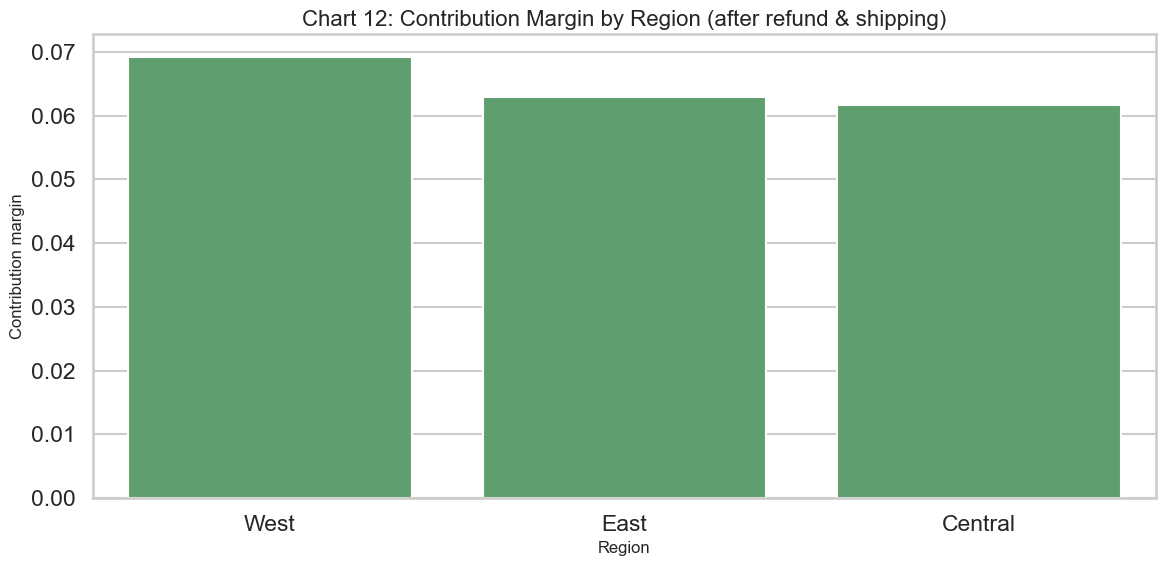

,region,orders,net_revenue,gross_profit,refund,shipping_fee,contribution_profit,contribution_margin
2,West,167642,3.670227e+09,3.787095e+08,1.237297e+08,791855.41,2.541880e+08,0.069257
1,East,294612,7.291151e+09,6.956483e+08,2.354817e+08,1244288.28,4.589223e+08,0.062942
0,Central,184691,4.719491e+09,4.430609e+08,1.513871e+08,773165.97,2.909007e+08,0.061638


In [5]:
# Chart 12 — Unit Economics waterfall theo region (bao gồm shipping + refund)
order_fin = line_items.groupby("order_id", as_index=False).agg(
    net_revenue=("net_revenue", "sum"),
    line_cogs=("line_cogs", "sum"),
    gross_profit=("gross_profit", "sum")
)

refund_order = returns.groupby("order_id", as_index=False).agg(refund_amount=("refund_amount", "sum"))
ship_fee_order = shipments.groupby("order_id", as_index=False).agg(shipping_fee=("shipping_fee", "sum"))
order_region = orders.merge(geography[["zip", "region"]].drop_duplicates("zip"), on="zip", how="left")[["order_id", "region"]]

unit = order_fin.merge(refund_order, on="order_id", how="left").merge(ship_fee_order, on="order_id", how="left").merge(order_region, on="order_id", how="left")
unit[["refund_amount", "shipping_fee"]] = unit[["refund_amount", "shipping_fee"]].fillna(0)
unit["contribution_profit"] = unit["gross_profit"] - unit["refund_amount"] - unit["shipping_fee"]
unit["contribution_margin"] = unit["contribution_profit"] / unit["net_revenue"]

region_unit = unit.groupby("region", as_index=False).agg(
    orders=("order_id", "nunique"),
    net_revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    refund=("refund_amount", "sum"),
    shipping_fee=("shipping_fee", "sum"),
    contribution_profit=("contribution_profit", "sum")
)
region_unit["contribution_margin"] = region_unit["contribution_profit"] / region_unit["net_revenue"]

plt.figure(figsize=(12, 6))
sns.barplot(data=region_unit.sort_values("contribution_margin", ascending=False), x="region", y="contribution_margin", color="#55A868")
plt.title("Chart 12: Contribution Margin by Region (after refund & shipping)")
plt.xlabel("Region")
plt.ylabel("Contribution margin")
plt.tight_layout()
plt.show()

display(region_unit.sort_values("contribution_margin", ascending=False))

**Phân tích Chart 12 (Diagnostic + Prescriptive)**

- **Điểm đặc biệt**: Khi tính đủ `refund + shipping`, thứ hạng lợi nhuận vùng có thể thay đổi so với chỉ nhìn gross margin.
- **Ý nghĩa kinh doanh**: Đây là chỉ số sát thực tế để quyết định mở rộng vùng, đàm phán logistics, và chính sách giao hàng.
- **Hành động**: Ưu tiên vùng có `contribution_margin` cao cho chiến dịch tăng trưởng; vùng thấp cần tối ưu delivery fee và giảm return.

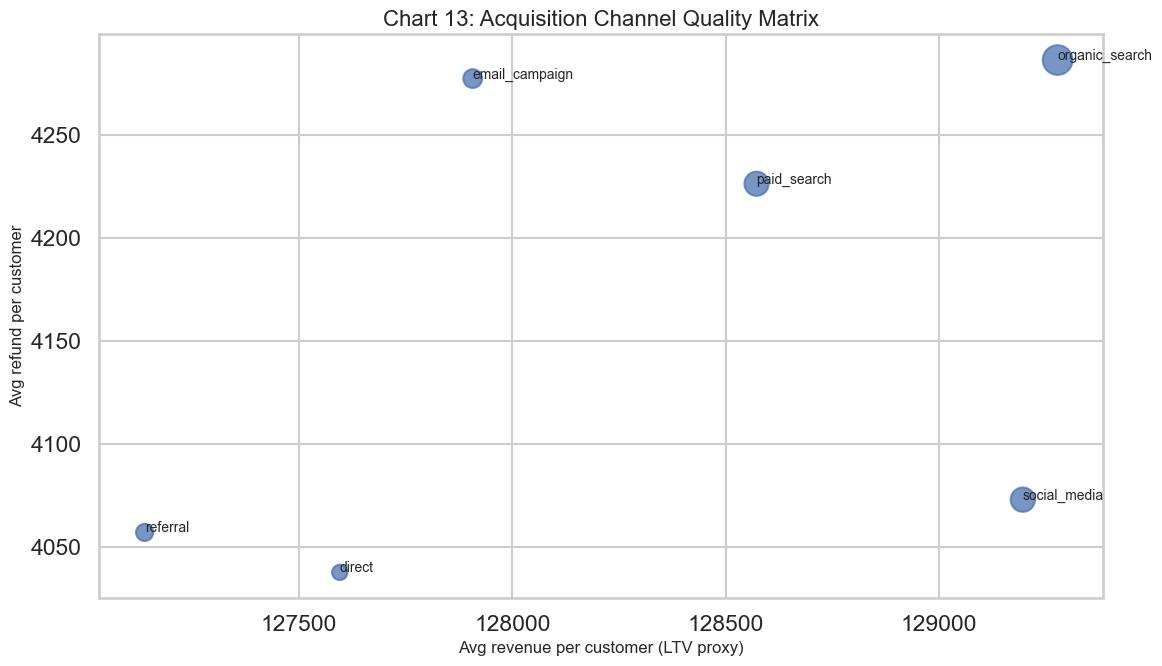

,acquisition_channel,customers,avg_ltv_proxy,avg_profit_proxy,avg_refund_per_customer,avg_return_rate
5,social_media,24448,129196.560267,12718.503728,4073.134942,0.040351
3,paid_search,24285,128572.341985,12594.326957,4226.496589,0.041240
1,email_campaign,14674,127906.935178,12414.707078,4277.550664,0.044211
2,organic_search,36450,129278.140767,12380.799657,4286.541437,0.041527
0,direct,9803,127595.257291,12202.786065,4037.826971,0.042683
4,referral,12270,127137.859000,12024.944259,4057.212893,0.041264


In [6]:
# Chart 13 — Acquisition channel quality matrix (LTV proxy vs refund burden)
cust_revenue = line_items.groupby("customer_id", as_index=False).agg(
    customer_revenue=("net_revenue", "sum"),
    customer_profit=("gross_profit", "sum"),
    customer_returns=("is_returned", "mean")
)

cust_refund = returns.merge(orders[["order_id", "customer_id"]], on="order_id", how="left").groupby("customer_id", as_index=False).agg(refund_amount=("refund_amount", "sum"))

channel_q = customers[["customer_id", "acquisition_channel"]].merge(cust_revenue, on="customer_id", how="left").merge(cust_refund, on="customer_id", how="left")
channel_q[["customer_revenue", "customer_profit", "customer_returns", "refund_amount"]] = channel_q[["customer_revenue", "customer_profit", "customer_returns", "refund_amount"]].fillna(0)

channel_m = channel_q.groupby("acquisition_channel", as_index=False).agg(
    customers=("customer_id", "nunique"),
    avg_ltv_proxy=("customer_revenue", "mean"),
    avg_profit_proxy=("customer_profit", "mean"),
    avg_refund_per_customer=("refund_amount", "mean"),
    avg_return_rate=("customer_returns", "mean")
)

plt.figure(figsize=(12, 7))
plt.scatter(channel_m["avg_ltv_proxy"], channel_m["avg_refund_per_customer"], s=channel_m["customers"]/80, alpha=0.75)
for _, r in channel_m.iterrows():
    plt.annotate(r["acquisition_channel"], (r["avg_ltv_proxy"], r["avg_refund_per_customer"]), fontsize=10)
plt.title("Chart 13: Acquisition Channel Quality Matrix")
plt.xlabel("Avg revenue per customer (LTV proxy)")
plt.ylabel("Avg refund per customer")
plt.tight_layout()
plt.show()

display(channel_m.sort_values("avg_profit_proxy", ascending=False))

**Phân tích Chart 13 (Insight kinh doanh trọng tâm)**

- **Điểm đặc biệt**: Cùng một kênh acquisition có thể mang doanh thu cao nhưng refund burden cũng cao, làm giảm giá trị ròng.
- **Ý nghĩa kinh doanh**: Nên tối ưu ngân sách theo **profit quality** thay vì chỉ volume khách mới.
- **Hành động**: Ưu tiên kênh có `avg_profit_proxy` cao và `avg_refund_per_customer` thấp; kênh còn lại áp dụng chiến dịch re-qualification.

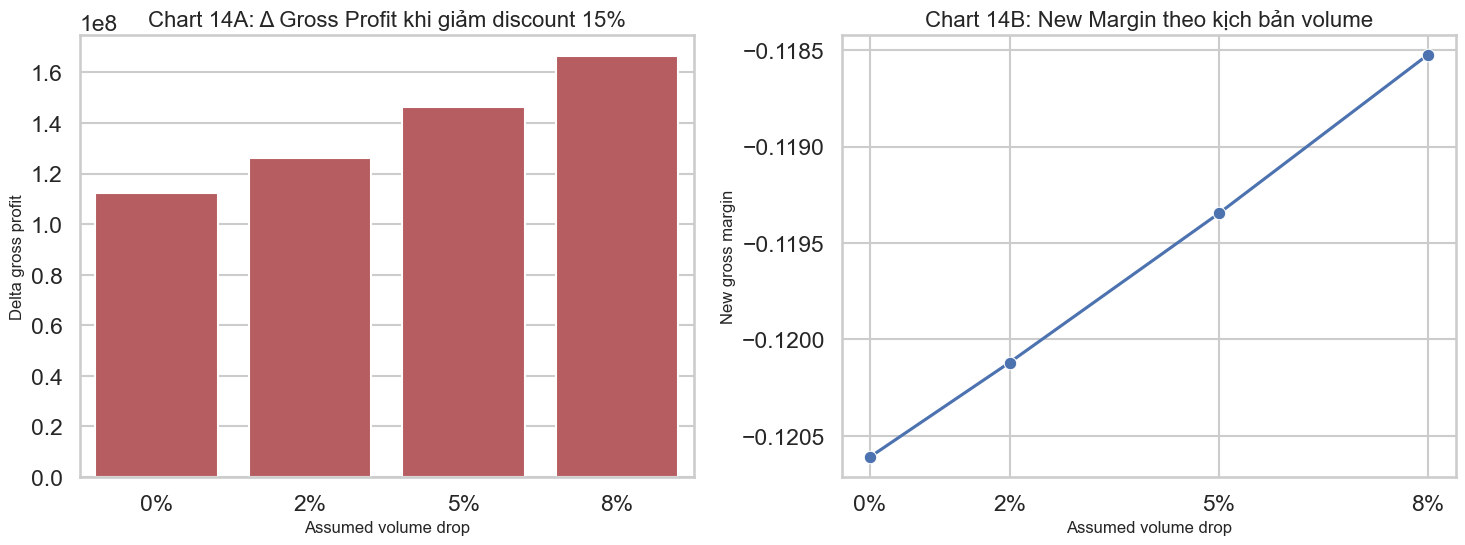

,volume_drop_pct,new_revenue,new_gross_profit,delta_gross_profit,new_margin
0,0.00,4.685830e+09,-5.651555e+08,1.124411e+08,-0.120609
1,0.02,4.592114e+09,-5.516036e+08,1.259930e+08,-0.120120
2,0.05,4.451539e+09,-5.312757e+08,1.463209e+08,-0.119347
3,0.08,4.310964e+09,-5.109478e+08,1.666488e+08,-0.118523


In [7]:
# Chart 14 — Prescriptive simulator: giảm discount trên promo lines
promo_lines = line_items[line_items["promo_applied"]].copy()
base_rev = promo_lines["net_revenue"].sum()
base_gp = promo_lines["gross_profit"].sum()
base_disc = promo_lines["discount_amount"].fillna(0).sum()

# Giả định: giảm discount 15% trên promo lines; thử các kịch bản mất volume
scenarios = []
for volume_drop in [0.00, 0.02, 0.05, 0.08]:
    new_discount = base_disc * 0.85
    recovered_discount = base_disc - new_discount

    new_revenue = base_rev * (1 - volume_drop)
    # Giả sử phần discount thu hồi chuyển hóa thành lợi nhuận, sau khi trừ phần mất GP do giảm volume
    gp_lost_from_volume = base_gp * volume_drop
    new_gp = base_gp + recovered_discount - gp_lost_from_volume

    scenarios.append({
        "volume_drop_pct": volume_drop,
        "new_revenue": new_revenue,
        "new_gross_profit": new_gp,
        "delta_gross_profit": new_gp - base_gp,
        "new_margin": new_gp / new_revenue if new_revenue else np.nan,
    })

sim = pd.DataFrame(scenarios)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=sim, x="volume_drop_pct", y="delta_gross_profit", ax=axes[0], color="#C44E52")
axes[0].set_title("Chart 14A: Δ Gross Profit khi giảm discount 15%")
axes[0].set_xlabel("Assumed volume drop")
axes[0].set_ylabel("Delta gross profit")
axes[0].set_xticklabels([f"{v:.0%}" for v in sim["volume_drop_pct"]])

sns.lineplot(data=sim, x="volume_drop_pct", y="new_margin", marker="o", ax=axes[1], color="#4C72B0")
axes[1].set_title("Chart 14B: New Margin theo kịch bản volume")
axes[1].set_xlabel("Assumed volume drop")
axes[1].set_ylabel("New gross margin")
axes[1].set_xticks(sim["volume_drop_pct"])
axes[1].set_xticklabels([f"{v:.0%}" for v in sim["volume_drop_pct"]])

plt.tight_layout()
plt.show()

display(sim)

**Phân tích Chart 14 (Prescriptive định lượng)**

- **Điểm đặc biệt**: Đây là mô phỏng đánh đổi “biên lợi nhuận vs nguy cơ giảm volume” thay vì đề xuất định tính.
- **Ý nghĩa kinh doanh**: Giúp quyết định ngưỡng discount an toàn theo khẩu vị rủi ro tăng trưởng.
- **Hành động**: Chạy thí điểm giảm discount trên 1-2 segment lớn trong 4 tuần, theo dõi `delta_gross_profit` thực tế so với mô phỏng.

In [8]:
# Rubric mapping table (self-check trước khi nộp)
rubric_check = pd.DataFrame([
    {"Rubric": "Chất lượng trực quan hoá (15)", "What covered": "14+ biểu đồ, tiêu đề + nhãn trục + chú giải, loại biểu đồ theo mục tiêu", "Evidence section": "Mục 2-14"},
    {"Rubric": "Chiều sâu phân tích (25)", "What covered": "Đủ Descriptive/Diagnostic/Predictive/Prescriptive + anomaly & scenario", "Evidence section": "Mục 2-14 + Chart 11-14"},
    {"Rubric": "Insight kinh doanh (15)", "What covered": "Action có KPI + đánh đổi định lượng (margin, refund, conversion)", "Evidence section": "Playbook + Chart 12-14"},
    {"Rubric": "Tính sáng tạo & kể chuyện (5)", "What covered": "Kết hợp đa bảng có chủ đích: traffic-order-inventory-logistics-refund", "Evidence section": "Master table + luồng storytelling"},
])
display(rubric_check)

,Rubric,What covered,Evidence section
0,Chất lượng trực quan hoá (15),"14+ biểu đồ, tiêu đề + nhãn trục + chú giải, l...",Mục 2-14
1,Chiều sâu phân tích (25),Đủ Descriptive/Diagnostic/Predictive/Prescript...,Mục 2-14 + Chart 11-14
2,Insight kinh doanh (15),"Action có KPI + đánh đổi định lượng (margin, r...",Playbook + Chart 12-14
3,Tính sáng tạo & kể chuyện (5),Kết hợp đa bảng có chủ đích: traffic-order-inv...,Master table + luồng storytelling


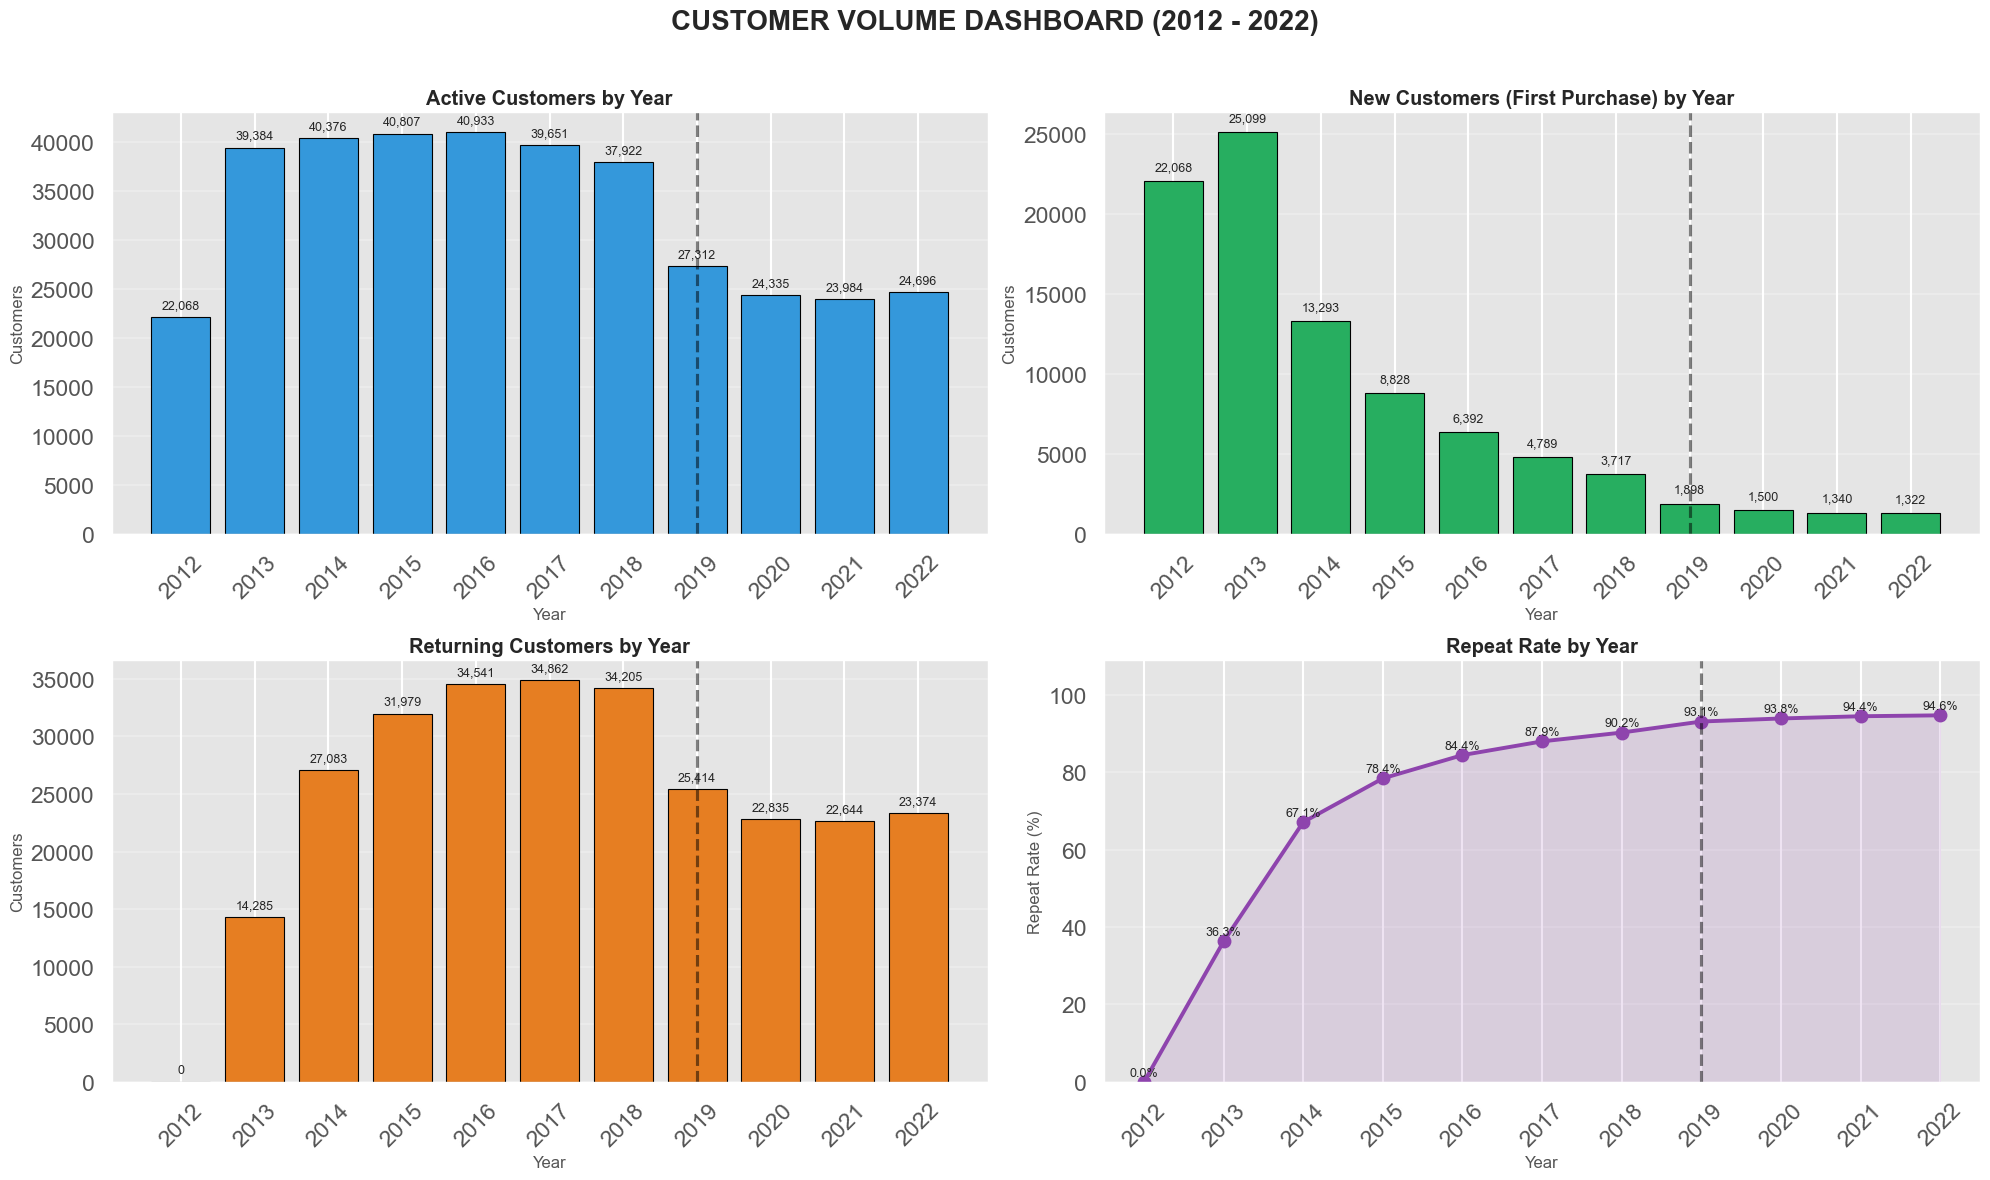

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.style.use('ggplot')

base_dir = Path(r'c:\Users\ADMIN\Documents\Datathon\datathon-2026-round-1')
orders = pd.read_csv(base_dir / 'orders.csv', parse_dates=['order_date'], low_memory=False)

orders_yearly = orders[['customer_id', 'order_date']].dropna().copy()
orders_yearly['year'] = orders_yearly['order_date'].dt.year

active_customers = orders_yearly.groupby('year')['customer_id'].nunique().reset_index(name='active_customers')
first_purchase = orders_yearly.groupby('customer_id')['year'].min().reset_index(name='first_purchase_year')
new_customers = first_purchase.groupby('first_purchase_year')['customer_id'].nunique().reset_index(name='new_customers')
new_customers.columns = ['year', 'new_customers']

customer_activity = orders_yearly.drop_duplicates(['customer_id', 'year'])
customer_activity = customer_activity.merge(first_purchase, on='customer_id', how='left')
customer_activity['is_returning'] = customer_activity['year'] > customer_activity['first_purchase_year']
returning_customers = customer_activity.groupby('year')['is_returning'].sum().reset_index(name='returning_customers')

customer_volume = active_customers.merge(new_customers, on='year', how='left').merge(returning_customers, on='year', how='left')
customer_volume[['new_customers', 'returning_customers']] = customer_volume[['new_customers', 'returning_customers']].fillna(0)
customer_volume['repeat_rate'] = np.where(
    customer_volume['active_customers'] > 0,
    customer_volume['returning_customers'] / customer_volume['active_customers'] * 100,
    np.nan,
)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('CUSTOMER VOLUME DASHBOARD (2012 - 2022)', fontsize=20, fontweight='bold', y=0.98)

axes[0, 0].bar(customer_volume['year'], customer_volume['active_customers'], color='#3498db', edgecolor='black', linewidth=0.8)
axes[0, 0].set_title('Active Customers by Year', fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Customers')
axes[0, 0].axvline(2019, color='black', linestyle='--', alpha=0.5)
for x, y in zip(customer_volume['year'], customer_volume['active_customers']):
    axes[0, 0].text(x, y + max(customer_volume['active_customers']) * 0.015, f'{y:,}', ha='center', va='bottom', fontsize=9)

axes[0, 1].bar(customer_volume['year'], customer_volume['new_customers'], color='#27ae60', edgecolor='black', linewidth=0.8)
axes[0, 1].set_title('New Customers (First Purchase) by Year', fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Customers')
axes[0, 1].axvline(2019, color='black', linestyle='--', alpha=0.5)
for x, y in zip(customer_volume['year'], customer_volume['new_customers']):
    axes[0, 1].text(x, y + max(customer_volume['new_customers']) * 0.02, f'{y:,}', ha='center', va='bottom', fontsize=9)

axes[1, 0].bar(customer_volume['year'], customer_volume['returning_customers'], color='#e67e22', edgecolor='black', linewidth=0.8)
axes[1, 0].set_title('Returning Customers by Year', fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Customers')
axes[1, 0].axvline(2019, color='black', linestyle='--', alpha=0.5)
for x, y in zip(customer_volume['year'], customer_volume['returning_customers']):
    axes[1, 0].text(x, y + max(customer_volume['returning_customers']) * 0.015, f'{y:,}', ha='center', va='bottom', fontsize=9)

axes[1, 1].plot(customer_volume['year'], customer_volume['repeat_rate'], color='#8e44ad', marker='o', linewidth=2.8)
axes[1, 1].fill_between(customer_volume['year'], customer_volume['repeat_rate'], alpha=0.15, color='#8e44ad')
axes[1, 1].set_title('Repeat Rate by Year', fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Repeat Rate (%)')
axes[1, 1].axvline(2019, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_ylim(0, max(customer_volume['repeat_rate'].max() * 1.15, 10))
for x, y in zip(customer_volume['year'], customer_volume['repeat_rate']):
    if pd.notna(y):
        axes[1, 1].text(x, y + 0.8, f'{y:.1f}%', ha='center', va='bottom', fontsize=9)

for ax in axes.flat:
    ax.set_xticks(customer_volume['year'])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()